## Settings and Utilities

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,         # base font size
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x, y axis labels
    'xtick.labelsize': 14,   # x-axis ticks
    'ytick.labelsize': 14,   # y-axis ticks
    'legend.fontsize': 14,   # legend
    'figure.titlesize': 18
})

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Shared utility functions

In [ ]:
import numpy as np
from scipy import signal

# The functions below are used across multiple sections of this notebook.
# Run this cell once, then any later section can be run on its own
# without needing to run every cell above it.

# Input : sig (signal), fs (sampling frequency)
# Output: f (one-sided frequency axis), mag (magnitude spectrum, |X|/N, no x2 factor)
def fft_oneside(sig, fs):
    N = len(sig)
    X = np.fft.rfft(sig)
    f = np.fft.rfftfreq(N, d=1/fs)
    mag = np.abs(X) / N
    return f, mag


# Input : x (signal), fs, nperseg, noverlap
# Output: STFT complex spectrogram (time x frequency)
def stft(x, fs, ax, shading='nearest'):
    nperseg = 128
    noverlap = nperseg * 3 // 4

    f, t, Zxx = signal.stft(x, fs, window='boxcar', nperseg=nperseg, noverlap=noverlap, nfft=nperseg, return_onesided=True, boundary=None, padded=False)

    Zxx_mag = np.abs(Zxx)

    im = ax.pcolormesh(t, f, Zxx_mag, shading=shading, cmap='jet', edgecolors='gray', linewidth=0.1)

    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    ax.set_ylim(0, fs/2)

    return im


# ============================================================
# Bearing fault frequency calculation
# ============================================================
# Input : D (pitch diameter), d (ball diameter), Nb (number of balls),
#         alpha (contact angle [rad]), fr (shaft rotational freq [Hz])
# Output: fault_freqs = [BPFO, BPFI, FTF, BSF] in Hz.
#         BSF is doubled (2x the raw ball-spin formula) because a
#         ball-surface defect strikes both the inner and outer race
#         once per ball rotation, so the defect shows up in the
#         spectrum at 2x the raw formula value, not at 1x.
#         Only the ratio d/D matters for BPFO/BPFI/FTF, so D and d
#         can be given as any two values with the correct ratio if
#         their absolute sizes are not known.
def calc_bearing_fault_freq(D, d, Nb, alpha, fr):
    bpfo = (Nb / 2) * fr * (1 - (d / D) * np.cos(alpha))
    bpfi = (Nb / 2) * fr * (1 + (d / D) * np.cos(alpha))
    ftf  = (fr / 2) * (1 - (d / D) * np.cos(alpha))
    bsf  = 2 * (D / (2 * d)) * fr * (1 - (d / D) ** 2 * np.cos(alpha) ** 2)
    return np.array([bpfo, bpfi, ftf, bsf])


# Vibration Signal Processing

## Signal Pre-processing

In [ ]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
# Example data

dt = 1
t = np.arange(0, 50, dt)
N = len(t)
z = 10 + 4 * np.random.randn(N)
# dt = 0.1 t = np.arange(0, 20, dt) N = len(t) z = t * np.sin(t)

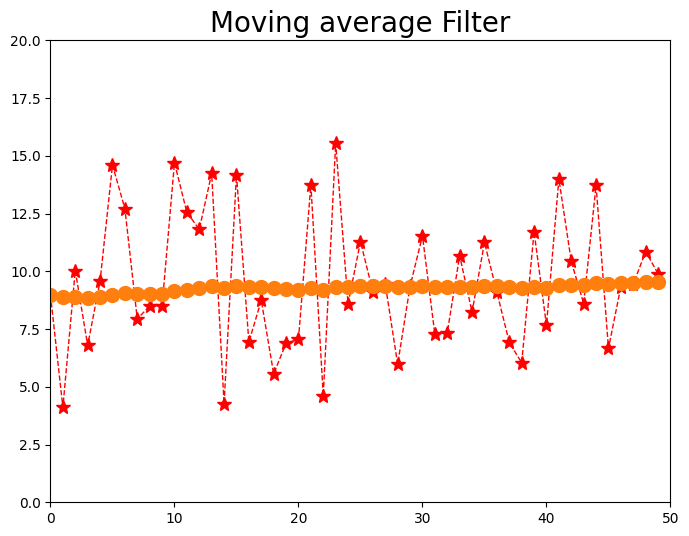

In [ ]:
# Simple moving average filter with window size n
n = 50
avg = np.zeros(N)
for k in range(N):
    if k == 0:
        xbun = z[k] * np.ones(n+1)
        avg0 = z[k]
    for m in range(n):
        xbun[m] = xbun[m+1]
    xbun[n] = z[k]
    avg[k] = avg0 + (z[k] - xbun[0]) / n
    avg0 = avg[k]

plt.figure(figsize=(8, 6))
plt.plot(t, z, 'r*--', markersize=10, linewidth=1)
plt.plot(t, avg, 'C1o-', markersize=10)
plt.title('Moving average Filter', fontsize=20)
plt.xlim([0, 50])
plt.ylim([0, 20])
plt.show()

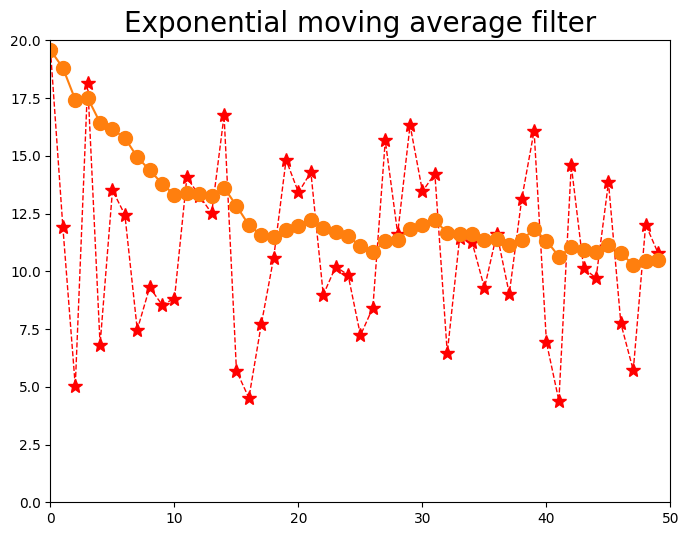

In [ ]:
# Exponential moving average filter with al

al = 0.1

avg0 = z[0]
avg = np.zeros(N)
avg[0] = z[0]

for k in range(1, N):
    for i in range(1, len(z)):
        avg[i] = al * z[i] + (1 - al) * avg[i-1]
    avg0 = np.sum(avg) # avg[k]

plt.figure(figsize=(8, 6))
plt.plot(t, z, 'r*--', markersize=10, linewidth=1)
plt.plot(t, avg, 'C1o-', markersize=10)
plt.title('Exponential moving average filter', fontsize=20)
plt.xlim([0, 50])
plt.ylim([0, 20])
plt.show()

In [ ]:
# Gaussain weighted filter with window size w
from scipy.signal import convolve

# Input : x (array), mu (mean), sigma (std dev)
# Output: Gaussian probability density evaluated at x
def gaussian(x):
    return np.exp(-np.power(x - np.mean(x), 2.) / (2 * np.power(np.std(x), 2.)))

# Input : x (signal), window_size, sigma
# Output: Gaussian-weighted moving-average filtered signal
def gaussian_weighted_filter(data, window_size):
    # Create Gaussian kernel
    x = np.linspace(-window_size//2, window_size//2, window_size)
    gaussian_kernel = gaussian(x)
    gaussian_kernel = gaussian_kernel / np.sum(gaussian_kernel)  # Normalize

    # Apply convolution
    filtered_data = convolve(data, gaussian_kernel, mode='same')

    return filtered_data

w = 5
avg = gaussian_weighted_filter(z, w)

plt.figure(figsize=(8, 6))
plt.plot(t, z, 'r*--', markersize=10, linewidth=1)
plt.plot(t, avg, 'C1o-', markersize=10)
plt.title('Gaussian weighted filter with w={}'.format(w), fontsize=20)
plt.xlim([0, 50])
plt.ylim([0, 20])
plt.show()

## Fast Fourier Transform

<Figure size 1000x400 with 0 Axes>

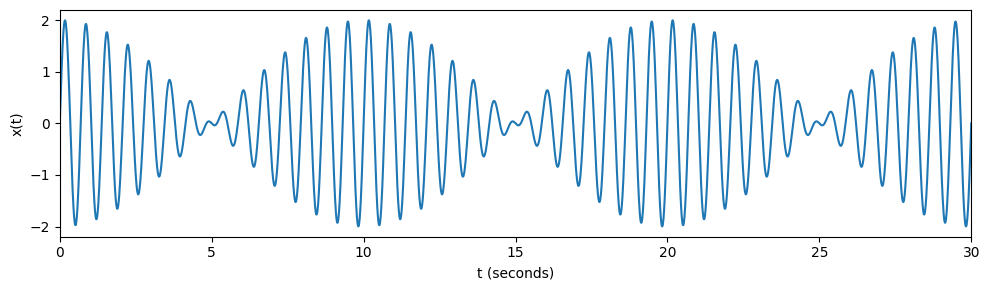

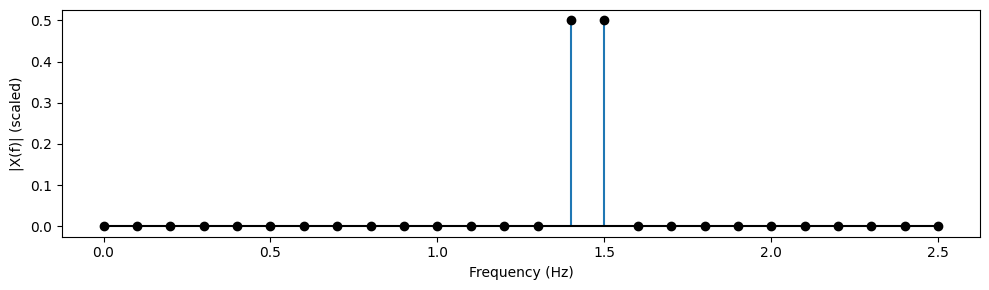

In [ ]:
# Two sine functions and its FFT

import numpy as np
import matplotlib.pyplot as plt

# Case setting
# case 1: p1 = 1.4
# case 2: p1 = np.sqrt(2)
A1, A2 = 1.0, 1.0
Theta1, Theta2 = 0.0, 0.0
p1, p2 = 1.4, 1.5  # change p1 if needed

# ----- Time-domain (continuous-time like sampling) -----
t = np.arange(0, 30.0 + 1e-12, 0.01)  # 0:0.01:30
x1 = A1 * np.sin(2*np.pi*p1*t + Theta1)
x2 = A2 * np.sin(2*np.pi*p2*t + Theta2)
x  = x1 + x2

plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.xlim(0, 30)
plt.xlabel("t (seconds)")
plt.ylabel("x(t)")
plt.tight_layout()

# ----- FFT part (discrete sampling) -----
fs = 5.0
T = 10.0
t = np.arange(0, T, 1/fs)  # 0:1/fs:T-1/fs

x1 = A1 * np.sin(2*np.pi*p1*t + Theta1)
x2 = A2 * np.sin(2*np.pi*p2*t + Theta2)
x  = x1 + x2

N = len(x)
X = np.fft.fft(x)
f = fs * np.arange(0, N) / N

Y = np.abs(X) / (fs * T)

half = N//2  # for even N
plt.figure(figsize=(10, 3))
plt.stem(f[:half+1], Y[:half+1], markerfmt='ko', basefmt='k-')
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)| (scaled)")
plt.tight_layout()

plt.show()


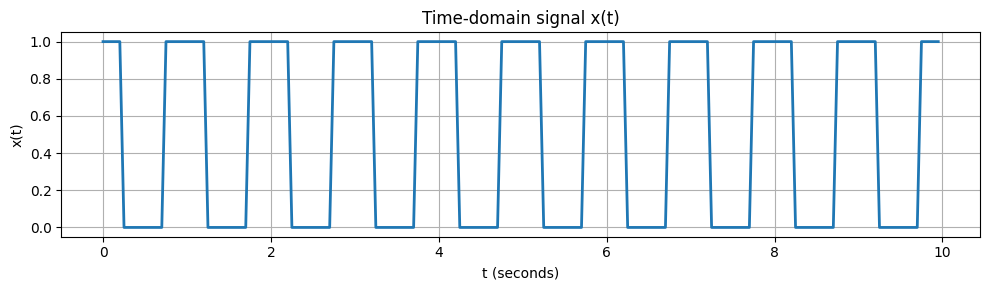

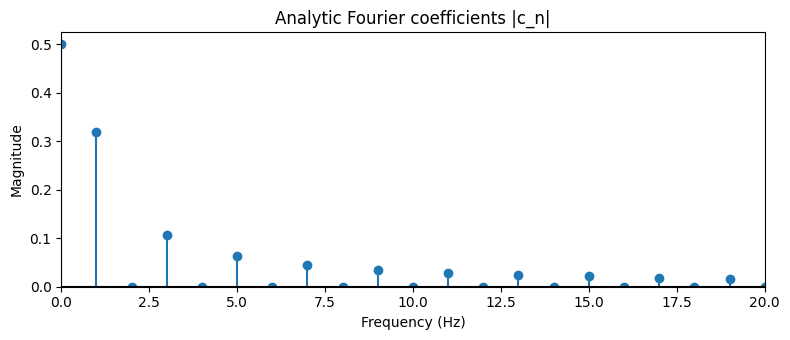

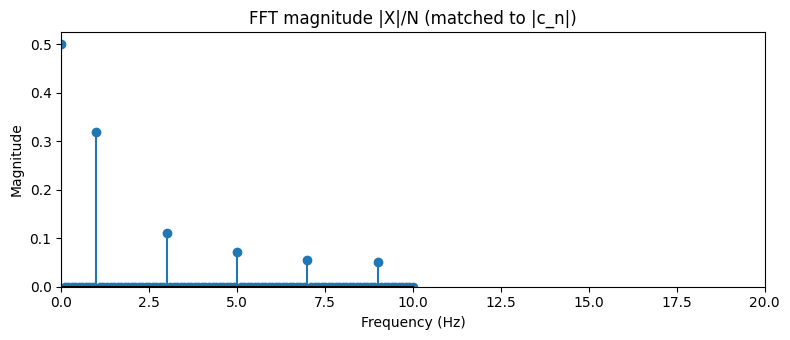

In [ ]:
# Fourier coefficients of square wave with width d

# 1) define x(t) and plot time-domain
# 2) compute analytic Fourier coefficients |c_n| and plot (frequency domain)
# 3) compute FFT, scale as |X[n]|/N to match |c_n|, and plot (frequency domain)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Define x(t): 0/1 rectangular pulse train
# -----------------------------
Tp = 1.0
d  = Tp / 2
fs = 20.0; r=10; T = r * Tp
t = np.arange(0, T, 1/fs)

# One-period construction (same shape as MATLAB: ones-zeros-ones)
n1 = int(round(fs * d / 2))        # ones at each end
n0 = int(round(fs * (Tp - d)))     # zeros in the middle
x_one_period = np.concatenate([np.ones(n1), np.zeros(n0), np.ones(n1)])
x = np.tile(x_one_period, r)

# Time axis for x (ensure same length)
t_x = np.arange(0, len(x)) / fs

plt.figure(figsize=(10, 3))
plt.plot(t_x, x, linewidth=2)
plt.xlabel("t (seconds)")
plt.ylabel("x(t)")
plt.title("Time-domain signal x(t)")
plt.grid(True)
plt.tight_layout()

# -----------------------------
# 2) Analytic Fourier coefficients |c_n|
#    c_n = (1/Tp) * integral_0^Tp x(t) e^{-j 2π n t/Tp} dt
#    For this rectangular pulse: |c_n| ~ (1/πn) sin(π d n / Tp), with DC term c_0 = d/Tp
# -----------------------------
n = np.arange(0, 21)   # 0..20 harmonics
fn = n / Tp            # harmonic frequencies (Hz)

cn = np.zeros_like(n, dtype=float)
cn[1:] = (1/np.pi) * (1/n[1:]) * np.sin(np.pi * d * n[1:] / Tp)
cn[0]  = d / Tp
cn = np.abs(cn)

# -----------------------------
# 3) FFT and scaling to match |c_n|
#    Discrete approximation: c_n ≈ (1/N) * FFT(x)[n]
# -----------------------------
N = len(x)
X = np.fft.fft(x)
f = fs * np.arange(0, N) / N

Y = np.abs(X) / N      # <-- key scaling to match |c_n|
half = N // 2          # left half (up to Nyquist)

# -----------------------------
# Match axis scales (x and y) between analytic and FFT plots
# -----------------------------
fmax = fn.max()
mask = f[:half+1] <= fmax
ymax = max(cn.max(), Y[:half+1][mask].max())

# Analytic plot
plt.figure(figsize=(8, 3.5))
# plt.plot(fn, cn)
plt.stem(fn, cn, basefmt="k-")
plt.xlim(0, fmax)
plt.ylim(0, 1.05*ymax)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Analytic Fourier coefficients |c_n|")
plt.tight_layout()

# FFT plot (same axis limits)
plt.figure(figsize=(8, 3.5))
plt.stem(f[:half+1], Y[:half+1], basefmt="k-")
plt.xlim(0, fmax)
plt.ylim(0, 1.05*ymax)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT magnitude |X|/N (matched to |c_n|)")
plt.tight_layout()

plt.show()

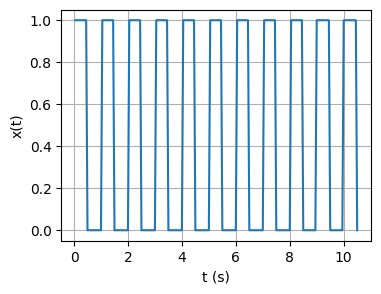

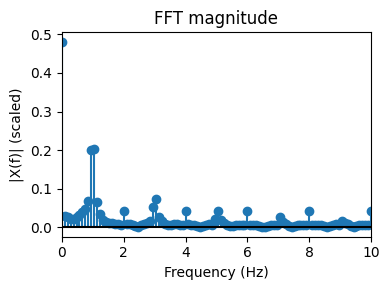

In [ ]:
# Effect of time window for square wave

import numpy as np
import matplotlib.pyplot as plt

Tp = 1.0
T  = 10.5* Tp            # 1, 2, 1.5, 10.5 can be tried
fs = 20.0

t = np.arange(1/fs, T + 1e-12, 1/fs)  # 1/fs : 1/fs : T
N = len(t)

# -----------------------------
# Generate xo(t)
# MATLAB logic: inside each period, xo = u(2πtt) - u(2π(tt-Tp/2))
# => since tt>0 in each period, u(2πtt)=1, so xo is 1 for tt <= Tp/2 else 0
# -----------------------------
xo = np.zeros(N)

for j, tj in enumerate(t):
    for i in range(1, 16):  # i = 1..15
        if (tj > (i-1)*Tp) and (tj <= i*Tp):
            tt = tj - (i-1)*Tp
            xo[j] = np.heaviside(2*np.pi*tt, 1.0) - np.heaviside(2*np.pi*(tt - Tp/2), 1.0)
            break

plt.figure(1,figsize=(4, 3))
plt.plot(t, xo)
plt.grid(True)
plt.xlabel("t (s)")
plt.ylabel("x(t)")

# -----------------------------
# FFT
# -----------------------------
X = np.fft.fft(xo)
f = fs * np.arange(0, N) / N

Y = np.abs(X) / (fs * T)  # match MATLAB: abs(X/fs/T)

half = N // 2
plt.figure(2,figsize=(4, 3))
plt.stem(f[:half+1], Y[:half+1], basefmt="k-")
plt.xlim(0, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)| (scaled)")
plt.title("FFT magnitude")
plt.tight_layout()

plt.show()

## Aliasing and Filtering

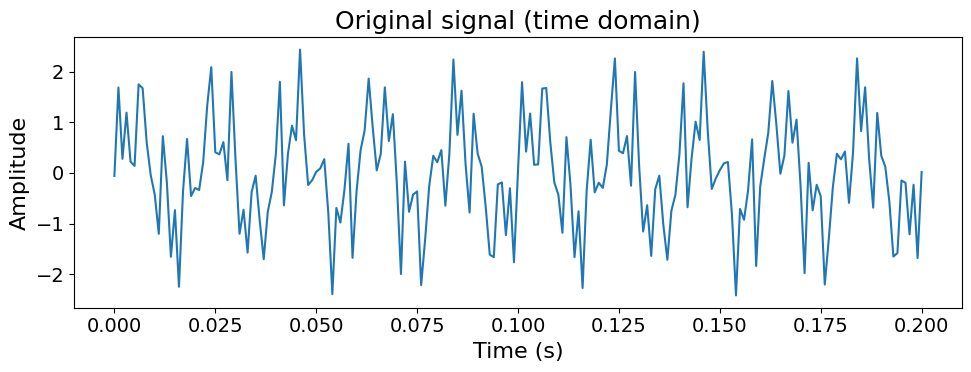

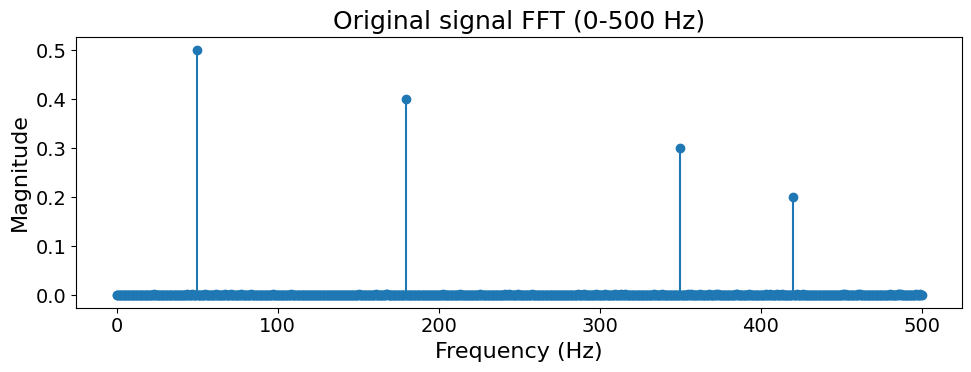

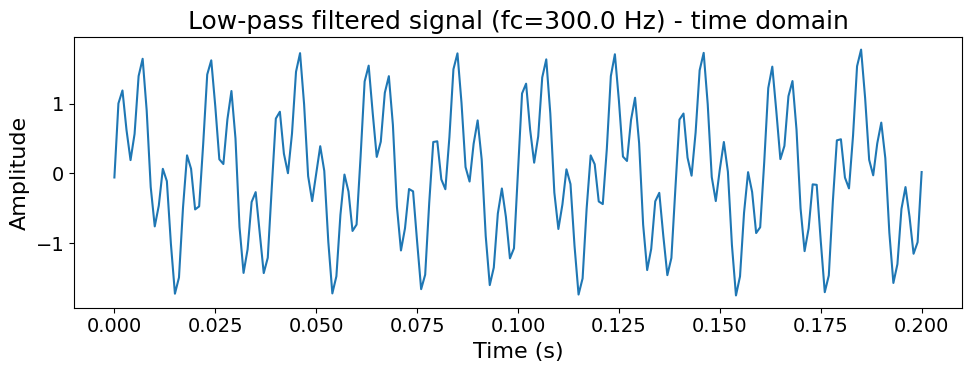

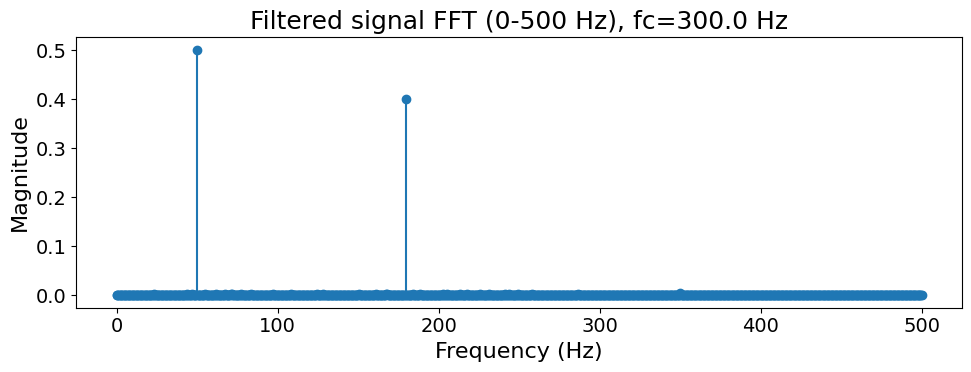

In [ ]:
# Filtering of mixture of sine waves

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

# (fft_oneside is defined in the "Settings and Utilities" section
#  at the top of this notebook)

# ----------------------------
# 1) Signal generation
# ----------------------------
fs = 1000.0                 # Hz
T  = 2.0                    # seconds
N  = int(fs * T)
t  = np.arange(N) / fs

# Low + High frequency mixture (arbitrary example)
# low components: 50 Hz, 180 Hz
# high components: 350 Hz, 420 Hz
x = (
    1.0*np.sin(2*np.pi*50*t) +
    0.8*np.sin(2*np.pi*180*t) +
    0.6*np.sin(2*np.pi*350*t) +
    0.4*np.sin(2*np.pi*420*t)
)

# optional: add small noise
x += 0.05*np.random.randn(N)

f, Xmag = fft_oneside(x, fs)

# ----------------------------
# 2) Low-pass filter (cutoff = 300 Hz)
#    Butterworth LPF (zero-phase)
# ----------------------------
fc = 300.0
order = 6
sos = butter(order, fc, btype='low', fs=fs, output='sos')
y = sosfiltfilt(sos, x)

f2, Ymag = fft_oneside(y, fs)

# ----------------------------
# 3) Plots
# ----------------------------
# time window to display (show first 0.2 sec for readability)
t_show = 0.2
idx = t <= t_show

plt.figure(figsize=(10, 4))
plt.plot(t[idx], x[idx])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original signal (time domain)')
plt.tight_layout()

plt.figure(figsize=(10, 4))
mask = (f >= 0) & (f <= 500)
plt.stem(f[mask], Xmag[mask], basefmt=' ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Original signal FFT (0-500 Hz)')
plt.tight_layout()

plt.figure(figsize=(10, 4))
plt.plot(t[idx], y[idx])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Low-pass filtered signal (fc={fc} Hz) - time domain')
plt.tight_layout()

plt.figure(figsize=(10, 4))
mask2 = (f2 >= 0) & (f2 <= 500)
plt.stem(f2[mask2], Ymag[mask2], basefmt=' ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title(f'Filtered signal FFT (0-500 Hz), fc={fc} Hz')
plt.tight_layout()

plt.show()


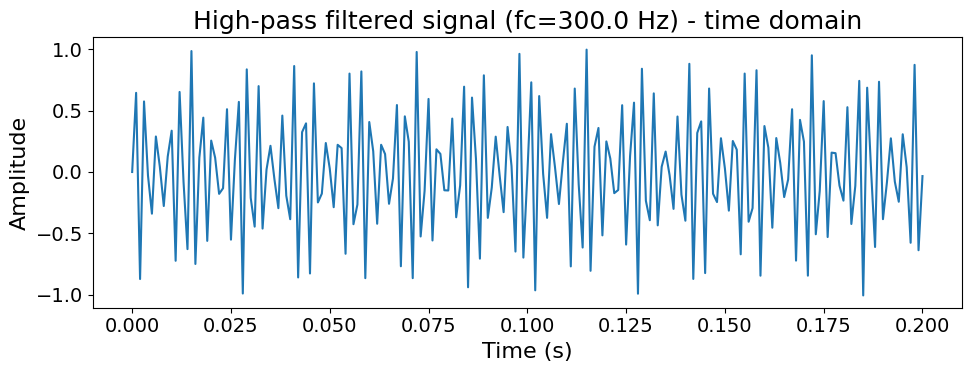

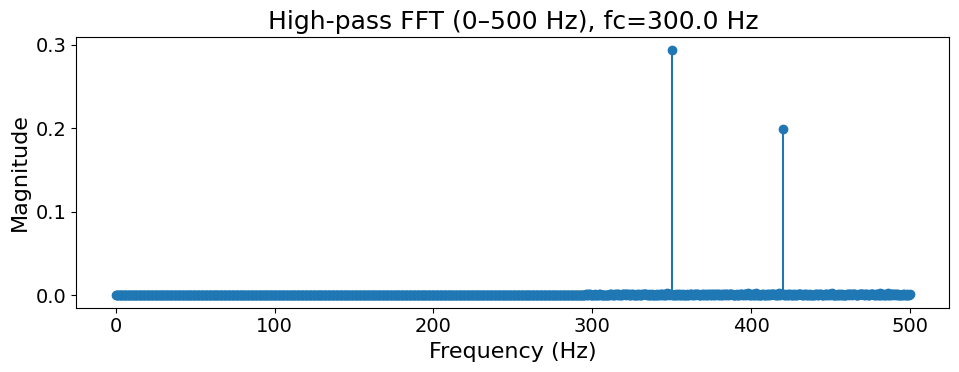

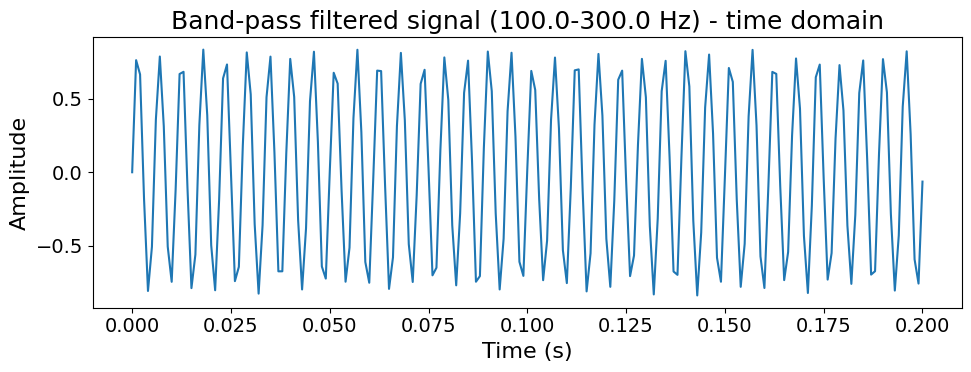

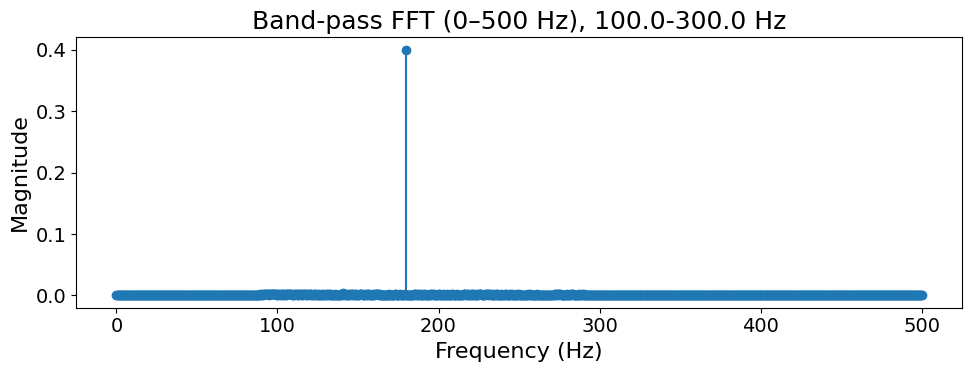

In [ ]:
# Filtering of mixture of sine waves (continued)

from scipy.signal import butter, sosfiltfilt

# --- High-pass (e.g., fc_hp = 300 Hz) ---
fc_hp = 300.0
order_hp = 6
sos_hp = butter(order_hp, fc_hp, btype='high', fs=fs, output='sos')
x_hp = sosfiltfilt(sos_hp, x)

f_hp, Xhp_mag = fft_oneside(x_hp, fs)

plt.figure(figsize=(10,4))
plt.plot(t[idx], x_hp[idx])
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.title(f'High-pass filtered signal (fc={fc_hp} Hz) - time domain')
plt.tight_layout()

plt.figure(figsize=(10,4))
m = (f_hp >= 0) & (f_hp <= 500)
plt.stem(f_hp[m], Xhp_mag[m], basefmt=' ')
plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude')
plt.title(f'High-pass FFT (0–500 Hz), fc={fc_hp} Hz')
plt.tight_layout()


# --- Band-pass (e.g., 100-300 Hz) ---
f1, f2c = 100.0, 300.0
order_bp = 6
sos_bp = butter(order_bp, [f1, f2c], btype='bandpass', fs=fs, output='sos')
x_bp = sosfiltfilt(sos_bp, x)

f_bp, Xbp_mag = fft_oneside(x_bp, fs)

plt.figure(figsize=(10,4))
plt.plot(t[idx], x_bp[idx])
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.title(f'Band-pass filtered signal ({f1}-{f2c} Hz) - time domain')
plt.tight_layout()

plt.figure(figsize=(10,4))
m = (f_bp >= 0) & (f_bp <= 500)
plt.stem(f_bp[m], Xbp_mag[m], basefmt=' ')
plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude')
plt.title(f'Band-pass FFT (0–500 Hz), {f1}-{f2c} Hz')
plt.tight_layout()

In [ ]:
# Filtering of real bearing signal (fault.lvm)

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

path = "/content/drive/MyDrive/PHM SUNYK/Datasets/Bearing_KAU/Innerrace_2.lvm"
raw = np.loadtxt(path)

t = raw[:,0].copy(); x = raw[:,1].copy()  # change to raw[:,2] or raw[:,3] if needed

# compute fs
dt_med = np.median(np.diff(t[1:]))
if (t[1] - t[0]) > 10 * dt_med:
    t[0] = t[1] - dt_med
dt = np.median(np.diff(t))
fs = 1.0/dt
print("shape:", raw.shape, "fs:", fs)

# (fft_oneside is already defined earlier in this notebook)

# filter design/apply
fc = 500.0
order = 6
sos_l = butter(order, fc, btype='low',  fs=fs, output='sos')
sos_h = butter(order, fc, btype='high', fs=fs, output='sos')

y_l = sosfiltfilt(sos_l, x)
y_h = sosfiltfilt(sos_h, x)

# FFT
f,  Xmag = fft_oneside(x,   fs)
fL, Lmag = fft_oneside(y_l, fs)
fH, Hmag = fft_oneside(y_h, fs)

# display window
t0 = t[0]
t_show = 0.05
idx = (t - t0) <= t_show
fmax_show = 1000.0

plt.figure(figsize=(10,3))
plt.plot(t[idx]-t0, x[idx])
plt.title("Raw (time)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.tight_layout()

plt.figure(figsize=(10,3))
m = (f>=0)&(f<=fmax_show)
plt.stem(f[m], Xmag[m], basefmt=' ');
plt.title("Raw FFT"); plt.xlabel("Hz"); plt.ylabel("Mag"); plt.tight_layout()

plt.figure(figsize=(10,3))
plt.plot(t[idx]-t0, y_l[idx])
plt.title("LPF 500 Hz (time)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.tight_layout()

plt.figure(figsize=(10,3))
m = (fL>=0)&(fL<=fmax_show)
plt.stem(fL[m], Lmag[m], basefmt=' ')
plt.title("LPF FFT"); plt.xlabel("Hz"); plt.ylabel("Mag"); plt.tight_layout()

plt.figure(figsize=(10,3))
plt.plot(t[idx]-t0, y_h[idx])
plt.title("HPF 500 Hz (time)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.tight_layout()

plt.figure(figsize=(10,3))
m = (fH>=0)&(fH<=fmax_show)
plt.stem(fH[m], Hmag[m], basefmt=' ')
plt.title("HPF FFT"); plt.xlabel("Hz"); plt.ylabel("Mag"); plt.tight_layout()

plt.show()


# Bearing signal processing

## Bearing life & fault characteristics

### Read FEMTO bearing data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# 1. Load .mat files
# ============================================================
base_path = "/content/drive/MyDrive/PHM SUNYK/Datasets/Bearing_FEMTO"

femto_path = f"{base_path}/femto.mat"
info_path  = f"{base_path}/info.mat"

mat = loadmat(femto_path)
info = loadmat(info_path)

# ============================================================
# 2. Check variables
# ============================================================
print('Variables in femto.mat\n')
for key, value in mat.items():
    if key.startswith('__'):
        continue
    arr = np.array(value)
    print(f'{key:10s} shape={arr.shape}, length={arr.size}, dtype={arr.dtype}')

print('\nVariables in info.mat\n')
for key, value in info.items():
    if key.startswith('__'):
        continue

    arr = np.array(value).squeeze()
    val = arr.item()

    if isinstance(val, float):
        print(f'{key:10s} = {val:.4f}')
    else:
        print(f'{key:10s} = {val}')

# ============================================================
# 3. Read sampling information from info.mat
# ============================================================
fs = float(np.squeeze(info['fs']))   # sampling rate [Hz]
sn = int(np.squeeze(info['sn']))     # samples per cycle

print(f'\nSampling rate fs = {fs} Hz')
print(f'Samples per cycle sn = {sn}')

# ============================================================
# 4. Plot original signals using cycle axis
# ============================================================
for k in range(1, 8):
    key = f'd{k}_x'
    sig = np.ravel(mat[key])

    N = len(sig)
    n_cycle = N // sn
    rem = N % sn

    print(f'\n{key}: total samples = {N}, total cycles = {n_cycle}, remainder = {rem}')

    # x-axis in cycle unit
    t = np.arange(N) / sn

    plt.figure(figsize=(10, 3))
    plt.plot(t, sig)
    plt.xlabel('Cycle')
    plt.ylabel(key)
    plt.title(f'Original Signal: {key}')
    plt.xlim(0, n_cycle)
    plt.ylim(-50, 50)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Simulation signal of bearing fault

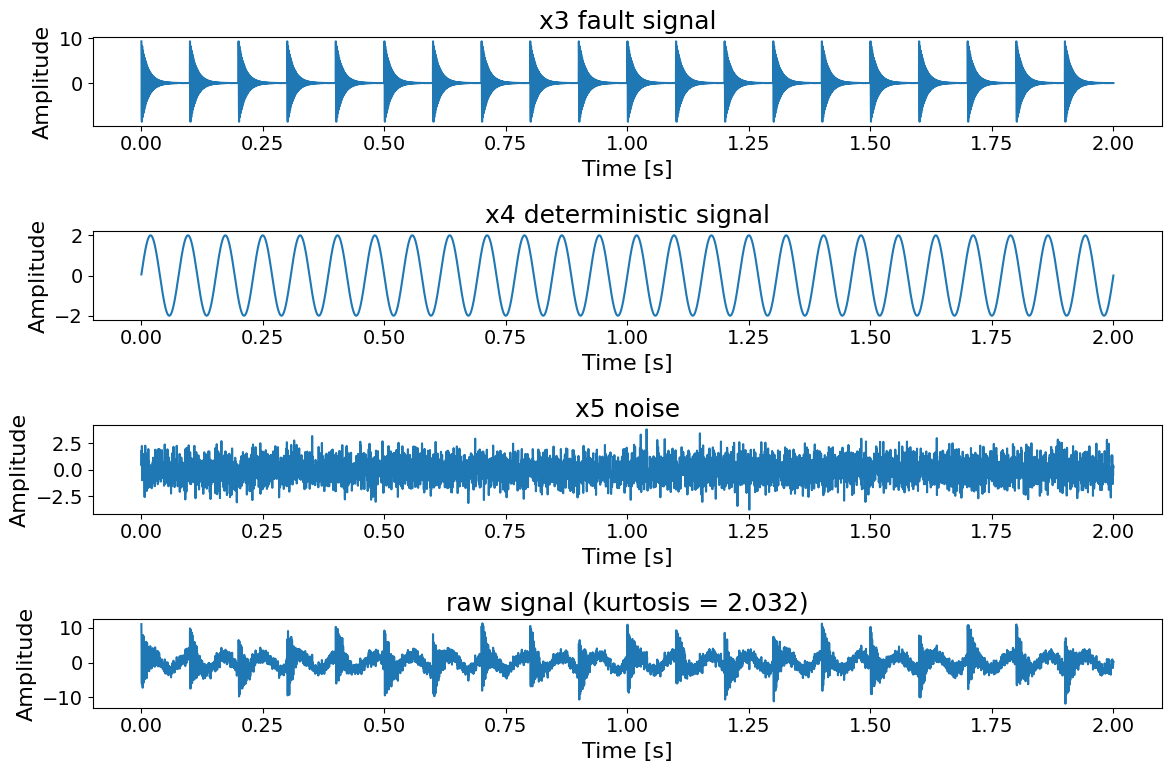

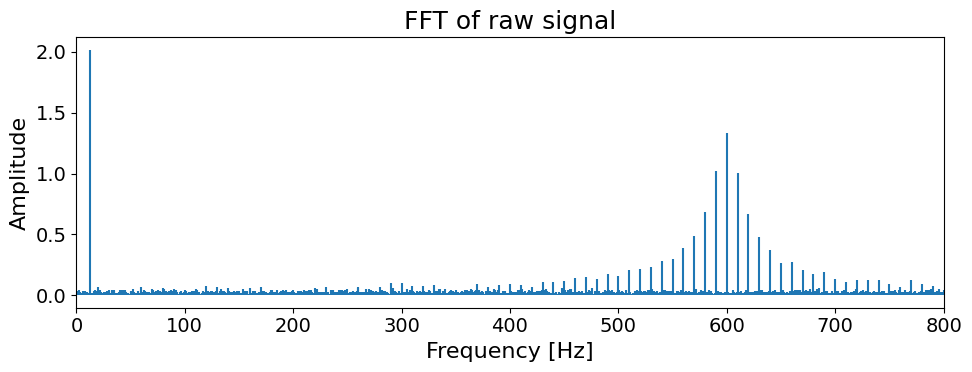

/tmp/ipykernel_566/3218865633.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


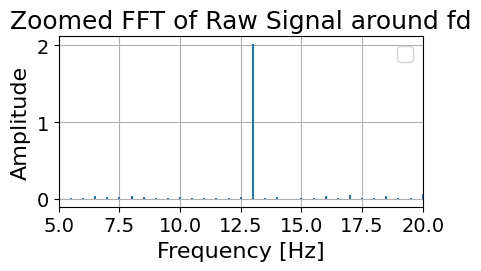

In [ ]:
# bearing fault simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window, butter, filtfilt, hilbert, lfilter
from scipy.stats import kurtosis
from scipy.linalg import toeplitz
from scipy.io import savemat, loadmat

# ============================================================
# 1. Signal generation of bearing fault simulation
# ============================================================
fr = 600        # Carrier frequency [Hz]
fd = 13         # Deterministic signal frequency [Hz]: original 13 only, new 55 & 115
fd2 = 115
ff = 10         # Fault characteristic frequency [Hz]
damp = 0.02     # Damping ratio
T = 1 / ff      # Fault repetition period [s]
fs = 3000       # Sampling rate [Hz]
K = 50          # Number of impulses
t = np.arange(1/fs, 2 + 1/fs, 1/fs)
Af = 5*2          # Maximum fault amplitude: original 5, new 5*2
Ad = 2          # Deterministic signal amplitude, original 2 only, new 1 & its 1/2
Ad2 = 0 # Ad/2
noise = 0.5*2   # Noise std; original 0.5, new 0.5*2

# fault-related impulsive signal
x3 = np.zeros_like(t)
for k in range(K):
    tau = t - k * T
    mask = tau >= 0
    x3[mask] += Af * np.exp(-damp * 2 * np.pi * fr * tau[mask]) * np.sin(2 * np.pi * fr * tau[mask])

# deterministic signal
x4 = Ad * np.sin(2 * np.pi * t * fd) + Ad2 * np.sin(2 * np.pi * t * fd2)

# noise
np.random.seed(0)
x5 = np.random.normal(0, noise, size=len(t))

# raw vibration signal
vib = x3 + x4 + x5

# ============================================================
# 2. Plot generated signals
# ============================================================
raw_kurt = kurtosis(vib, fisher=True, bias=False)

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(t, x3)
plt.title('x3 fault signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(4, 1, 2)
plt.plot(t, x4)
plt.title('x4 deterministic signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(4, 1, 3)
plt.plot(t, x5)
plt.title('x5 noise')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.subplot(4, 1, 4)
plt.plot(t, vib)
plt.title(f'raw signal (kurtosis = {raw_kurt:.3f})')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

# raw signal FFT
Nraw = len(vib)
fftRaw = np.abs(np.fft.fft(vib)) / Nraw * 2
freqRaw = np.arange(Nraw) / Nraw * fs

plt.figure(figsize=(10, 4))
plt.stem(freqRaw[:Nraw//2], fftRaw[:Nraw//2], linefmt='C0-', markerfmt=' ', basefmt=' ')
plt.title('FFT of raw signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim([0, 800])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Zoomed FFT around low-frequency peak with 13 Hz marker
# ------------------------------------------------------------
plt.figure(figsize=(5, 3))
plt.stem(freqRaw, fftRaw, linefmt='C0-', markerfmt=' ', basefmt=' ')
plt.title("Zoomed FFT of Raw Signal around fd")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(5, 20)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

savemat('/content/drive/MyDrive/PHM SUNYK/Datasets/Simulation_Bearing.mat', {'vib': vib, 't': t})

## Bearing signal processing procedure

### Kurtosis of simulation signal

norm kurtosis = -0.72592
fault kurtosis = 2.03202


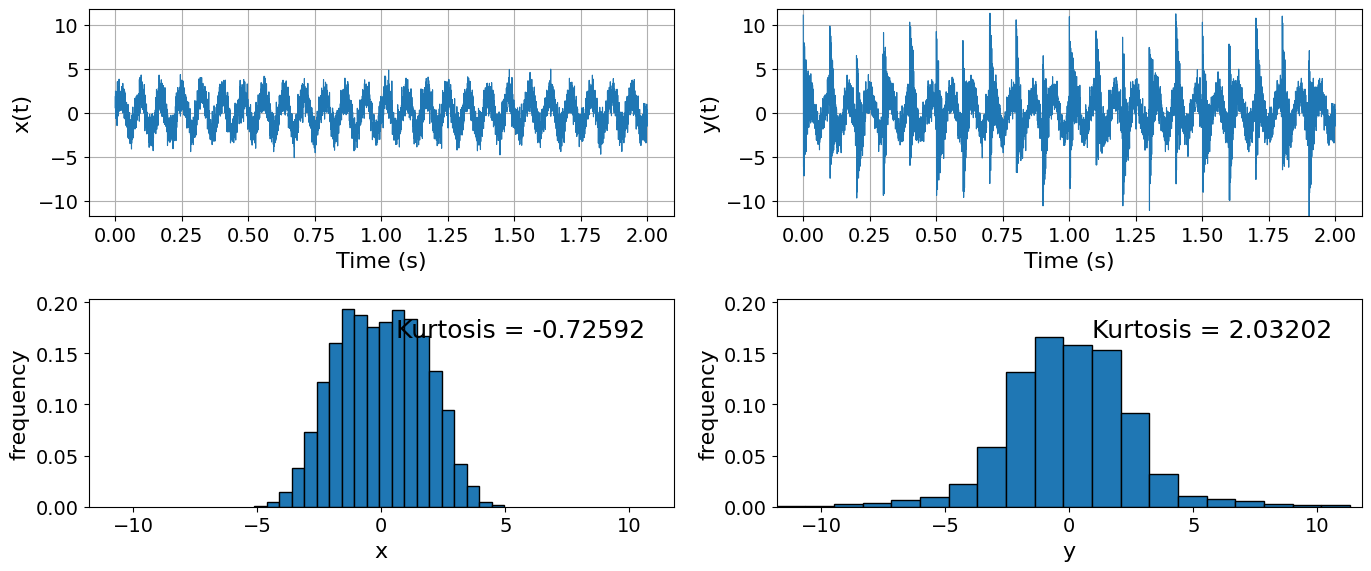

In [ ]:
from scipy.stats import kurtosis

x_norm = x4+x5
x_fault = x3+x4+x5

fs = 3000       # Sampling rate [Hz]
t = np.arange(1/fs, 2 + 1/fs, 1/fs)

k_norm = kurtosis(x_norm, fisher=True, bias=False)
k_fault  = kurtosis(x_fault,  fisher=True, bias=False)

print(f'norm kurtosis = {k_norm:.5f}')
print(f'fault kurtosis = {k_fault:.5f}')

# 6) Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

axes[0, 0].plot(t, x_norm, linewidth=0.8)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('x(t)')
axes[0, 0].grid(True)

axes[1, 0].hist(x_norm, bins=20, density=True, edgecolor='black')
axes[1, 0].text(0.95, 0.85, f'Kurtosis = {k_norm:.5f}',
                transform=axes[1, 0].transAxes,
                ha='right', va='center', fontsize=18)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('frequency')

axes[0, 1].plot(t, x_fault, linewidth=0.8)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('y(t)')
axes[0, 1].grid(True)

axes[1, 1].hist(x_fault, bins=20, density=True, edgecolor='black')
axes[1, 1].text(0.95, 0.85, f'Kurtosis = {k_fault:.5f}',
                transform=axes[1, 1].transAxes,
                ha='right', va='center', fontsize=18)
axes[1, 1].set_xlabel('y')
axes[1, 1].set_ylabel('frequency')

# Unify y-axis across the upper time-domain signal plots
ylim = max(np.max(np.abs(x_norm)), np.max(np.abs(x_fault)))
axes[0, 0].set_ylim(-ylim, ylim)
axes[0, 1].set_ylim(-ylim, ylim)

# Unify x-axis across the lower histogram plots
xlim = ylim
axes[1, 0].set_xlim(-xlim, xlim)
axes[1, 1].set_xlim(-xlim, xlim)

# Unify y-axis across the lower histogram plots
hist_ylim = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
axes[1, 0].set_ylim(0, hist_ylim)
axes[1, 1].set_ylim(0, hist_ylim)

plt.tight_layout()
plt.show()


### Kurtosis of real bearing fault signal

First 2560 samples kurtosis = -0.12937
Last  2560 samples kurtosis = 8.03887


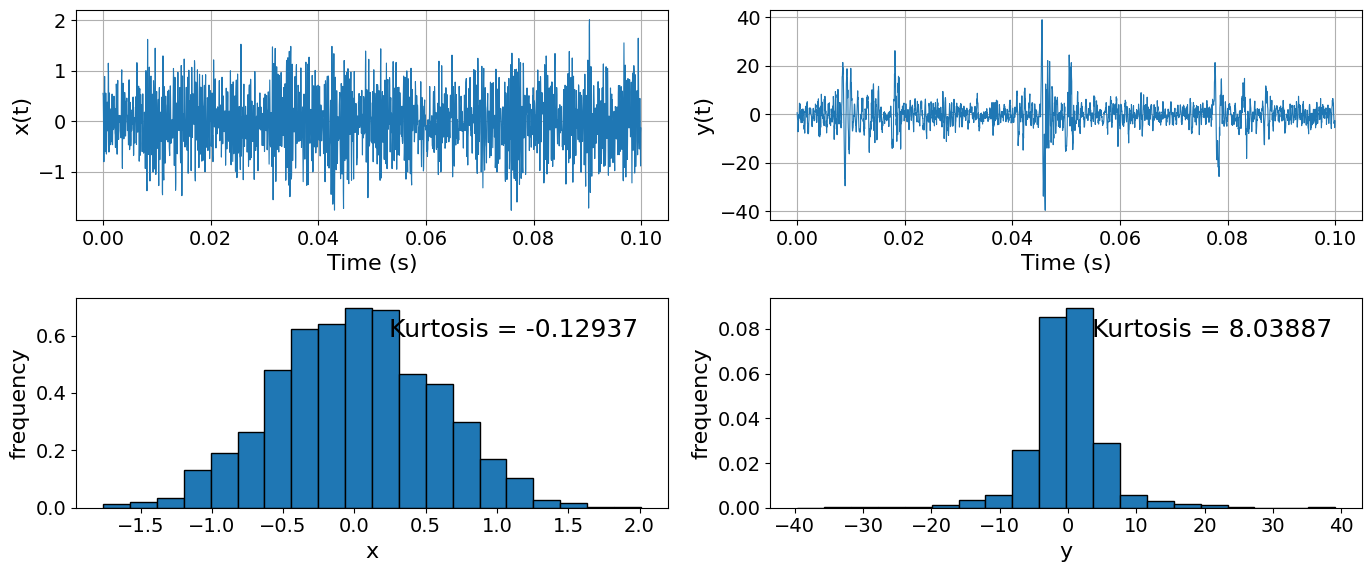

In [ ]:
# Features of bearing fault signal
# continued from previous FEMTO

from scipy.stats import kurtosis
x = np.ravel(mat['d1_x'])

# 3) Extract the first 2560 and last 2560 samples
n = 2560
x_first = x[:n]
x_last  = x[-n:]

# 4) Create time axis
fs = 25600
t = np.arange(n) / fs

# 5) Compute kurtosis
# fisher=False : Pearson kurtosis (normal distribution baseline = 3)
# fisher=True  : excess kurtosis (normal distribution baseline = 0)
k_first = kurtosis(x_first, fisher=True, bias=False)
k_last  = kurtosis(x_last,  fisher=True, bias=False)

print(f'First 2560 samples kurtosis = {k_first:.5f}')
print(f'Last  2560 samples kurtosis = {k_last:.5f}')

# 6) Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# Top-left: first 2560 samples, raw signal
axes[0, 0].plot(t, x_first, linewidth=0.8)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('x(t)')
axes[0, 0].grid(True)

# Bottom-left: first 2560 samples, histogram
axes[1, 0].hist(x_first, bins=20, density=True, edgecolor='black')
axes[1, 0].text(0.95, 0.85, f'Kurtosis = {k_first:.5f}',
                transform=axes[1, 0].transAxes,
                ha='right', va='center', fontsize=18)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('frequency')

# Top-right: last 2560 samples, raw signal
axes[0, 1].plot(t, x_last, linewidth=0.8)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('y(t)')
axes[0, 1].grid(True)

# Bottom-right: last 2560 samples, histogram
axes[1, 1].hist(x_last, bins=20, density=True, edgecolor='black')
axes[1, 1].text(0.95, 0.85, f'Kurtosis = {k_last:.5f}',
                transform=axes[1, 1].transAxes,
                ha='right', va='center', fontsize=18)
axes[1, 1].set_xlabel('y')
axes[1, 1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

## AR Filtering

### AR Model of sine wave

Best p by minimum AIC      = 7
Best p by maximum kurtosis = 4

p    AIC          Kurtosis      RMS
---------------------------------------------
 2     -2595.63       0.0208    0.12601
 3     -2645.26       0.0026    0.12053
 4     -2662.23       0.0511    0.11832
 5     -2695.13      -0.1333    0.11467
 6     -2702.06      -0.1550    0.11346
 7     -2713.01      -0.1474    0.11189
 8     -2709.77      -0.1143    0.11161
 9     -2704.40      -0.1324    0.11152
10     -2697.03      -0.1384    0.11161


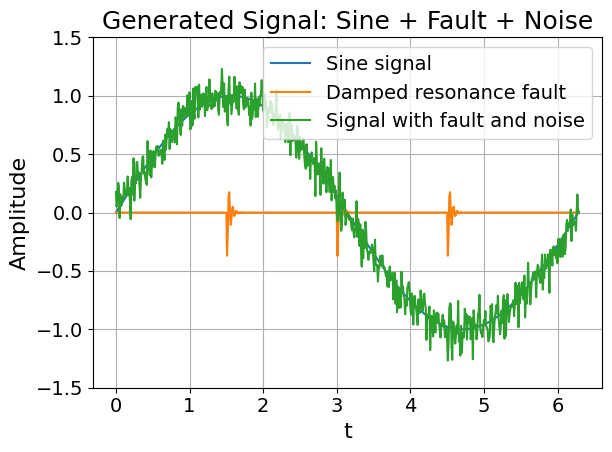

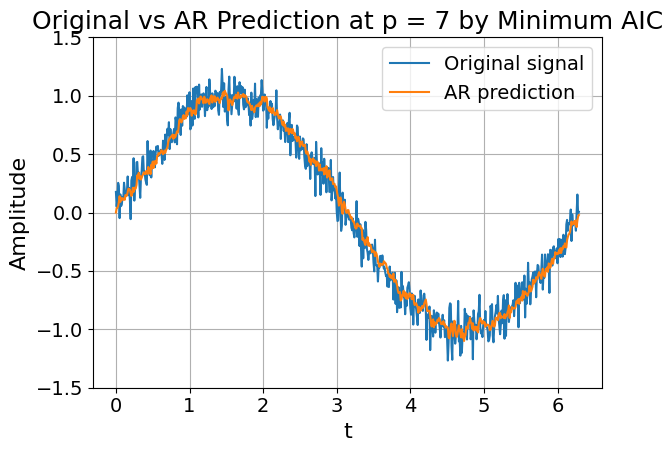

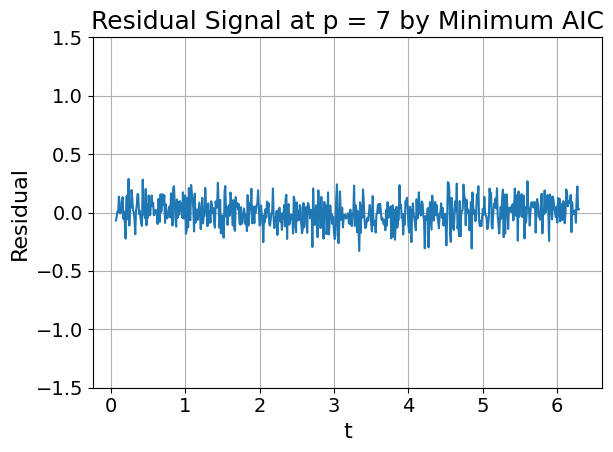

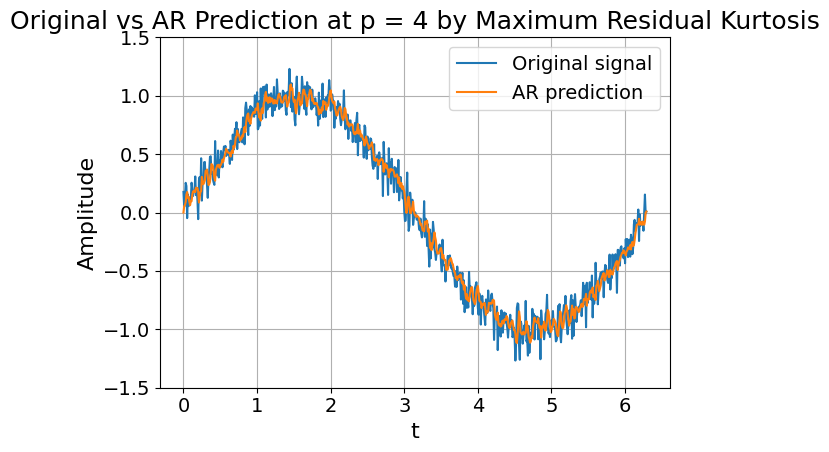

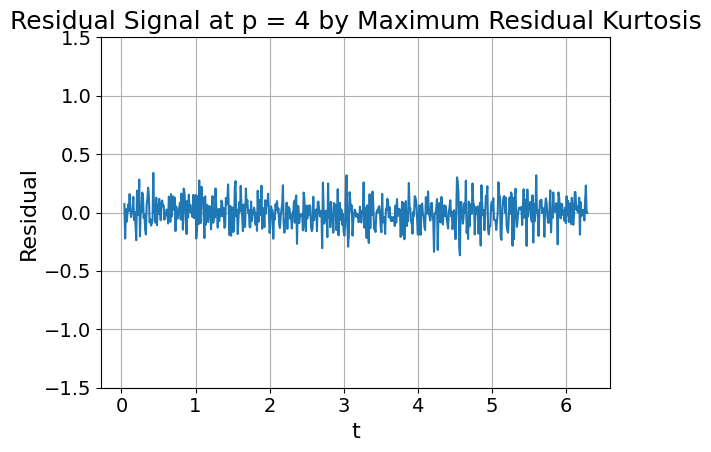

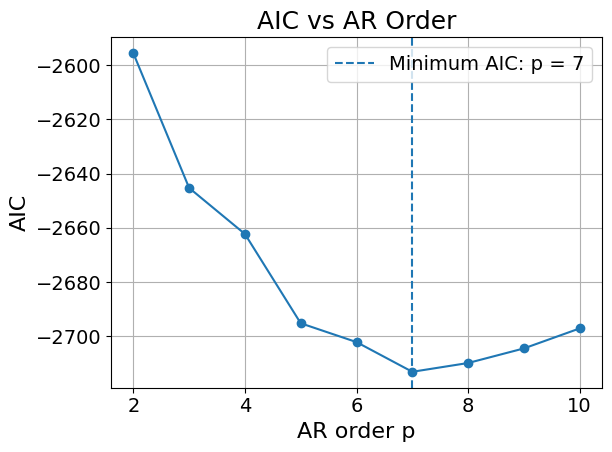

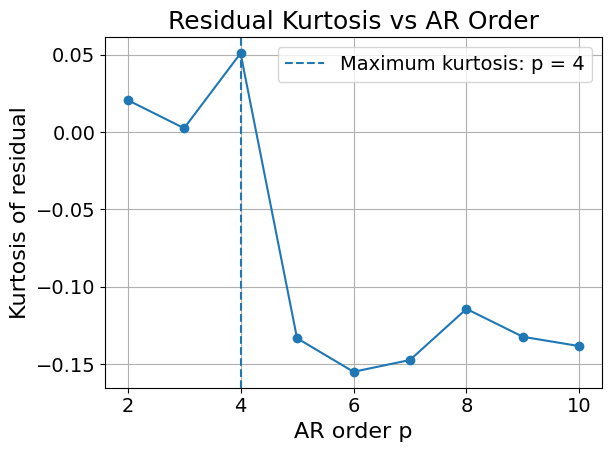

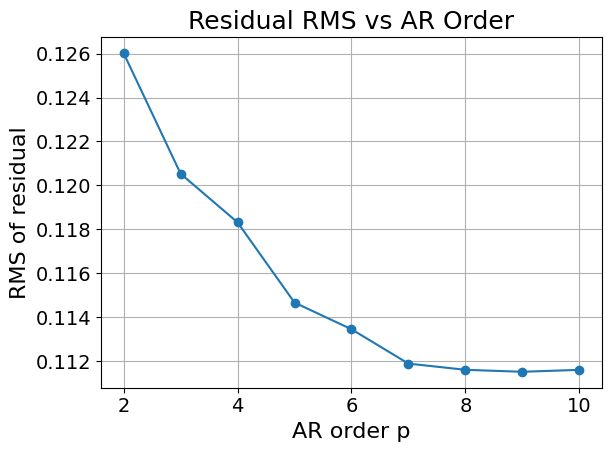

In [ ]:
# AR model of sine wave with noise and fault
# AR order selection using AIC and residual kurtosis

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import yule_walker
from scipy.stats import kurtosis

# ----------------------------
# 1) Signal generation
# ----------------------------
t = np.arange(0, 2*np.pi + 0.01, 0.01)
n = len(t)

# Base sine signal
base = np.sin(t)

# Fault-related impulsive resonance signal
fault = np.zeros_like(t)

impact_times = [1.5, 3.0, 4.5]   # fault impact locations

A = 0.5          # impact amplitude
fr = 80          # resonance frequency [Hz]; adjust to match rad/time axis if needed
damp = 0.05      # damping ratio-like parameter

for tc in impact_times:
    tau = t - tc
    mask = tau >= 0

    fault[mask] += A * np.exp(-damp * 2 * np.pi * fr * tau[mask]) * np.sin(2 * np.pi * fr * tau[mask])

# Noise
noise_std = 0.1
np.random.seed(0)
noise = np.random.normal(0, noise_std, size=n)

# Final signal
x = base + fault + noise

# ----------------------------
# 2) Plot generated signal
# ----------------------------
plt.figure()
plt.plot(t, base, label="Sine signal")
plt.plot(t, fault, label="Damped resonance fault")
plt.plot(t, x, label="Signal with fault and noise")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Generated Signal: Sine + Fault + Noise")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.tight_layout()

# ----------------------------
# 3) AR order sweep
# ----------------------------
p_list = np.arange(2, 11)

aic_vals = []
kurt_vals = []
rms_vals = []

xp_dict = {}
res_dict = {}

for p in p_list:
    # Yule-Walker AR coefficients
    rho, sigma = yule_walker(x, order=p, method="mle")

    # One-step prediction
    xp = np.zeros_like(x)

    for k in range(1, p + 1):
        xp[k:] += rho[k - 1] * x[:-k]

    # Residual
    res = x - xp

    # Exclude first p samples
    res_eff = res[p:]

    # Save prediction and residual
    xp_dict[p] = xp
    res_dict[p] = res

    # AIC
    sigma2 = np.mean(res_eff ** 2)
    N_eff = len(res_eff)
    k_param = p + 1

    aic = N_eff * np.log(sigma2) + 2 * k_param
    aic_vals.append(aic)

    # Kurtosis of residual
    # fisher=True means normal distribution has kurtosis = 3
    kurt_val = kurtosis(res_eff, fisher=True)
    kurt_vals.append(kurt_val)

    # RMS of residual, used only as a reference
    rms_val = np.sqrt(np.mean(res_eff ** 2))
    rms_vals.append(rms_val)

aic_vals = np.array(aic_vals)
kurt_vals = np.array(kurt_vals)
rms_vals = np.array(rms_vals)

# ----------------------------
# 4) Select AR order
# ----------------------------
p_aic = p_list[np.argmin(aic_vals)]
p_kurt = p_list[np.argmax(kurt_vals)]

print(f"Best p by minimum AIC      = {p_aic}")
print(f"Best p by maximum kurtosis = {p_kurt}")

print()
print("p    AIC          Kurtosis      RMS")
print("-" * 45)

for p, aic, kur, rms in zip(p_list, aic_vals, kurt_vals, rms_vals):
    print(f"{p:2d}   {aic:10.2f}   {kur:10.4f}   {rms:8.5f}")

# ============================================================
# 5) Results using minimum AIC
# ============================================================
xp_aic = xp_dict[p_aic]
res_aic = res_dict[p_aic]

plt.figure()
plt.plot(t, x, label="Original signal")
plt.plot(t, xp_aic, label="AR prediction")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title(f"Original vs AR Prediction at p = {p_aic} by Minimum AIC")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(t[p_aic:], res_aic[p_aic:])
plt.xlabel("t")
plt.ylabel("Residual")
plt.title(f"Residual Signal at p = {p_aic} by Minimum AIC")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.tight_layout()

# ============================================================
# 6) Results using maximum residual kurtosis
# ============================================================
xp_kurt = xp_dict[p_kurt]
res_kurt = res_dict[p_kurt]

plt.figure()
plt.plot(t, x, label="Original signal")
plt.plot(t, xp_kurt, label="AR prediction")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title(f"Original vs AR Prediction at p = {p_kurt} by Maximum Residual Kurtosis")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(t[p_kurt:], res_kurt[p_kurt:])
plt.xlabel("t")
plt.ylabel("Residual")
plt.title(f"Residual Signal at p = {p_kurt} by Maximum Residual Kurtosis")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.tight_layout()

# ============================================================
# 7) AIC, kurtosis, and RMS vs AR order
# ============================================================
plt.figure()
plt.plot(p_list, aic_vals, marker="o")
plt.axvline(p_aic, linestyle="--", label=f"Minimum AIC: p = {p_aic}")
plt.xlabel("AR order p")
plt.ylabel("AIC")
plt.title("AIC vs AR Order")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(p_list, kurt_vals, marker="o")
plt.axvline(p_kurt, linestyle="--", label=f"Maximum kurtosis: p = {p_kurt}")
plt.xlabel("AR order p")
plt.ylabel("Kurtosis of residual")
plt.title("Residual Kurtosis vs AR Order")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure()
plt.plot(p_list, rms_vals, marker="o")
plt.xlabel("AR order p")
plt.ylabel("RMS of residual")
plt.title("Residual RMS vs AR Order")
plt.grid(True)
plt.tight_layout()

plt.show()

### AR model of simulation signal

AR order selected by residual kurtosis criterion = 112


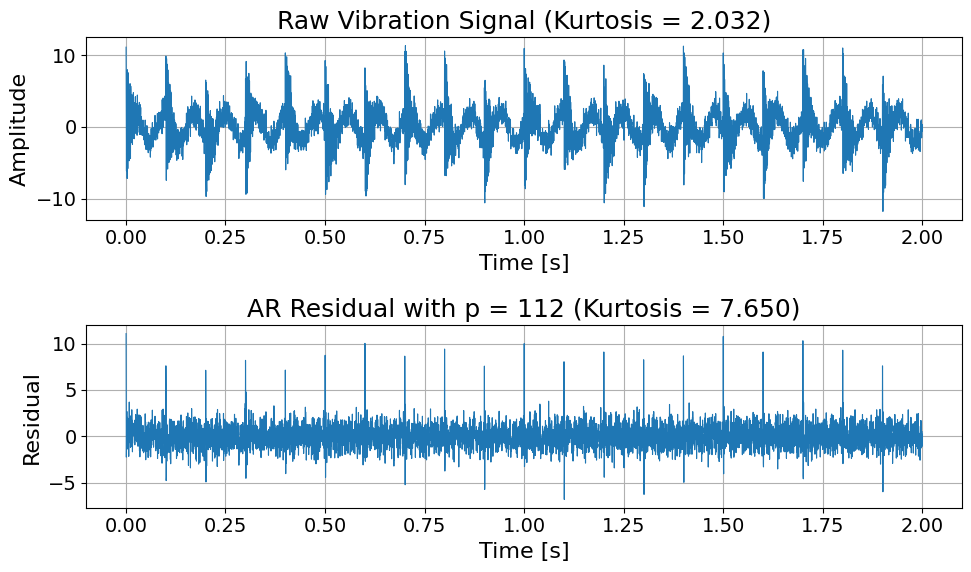

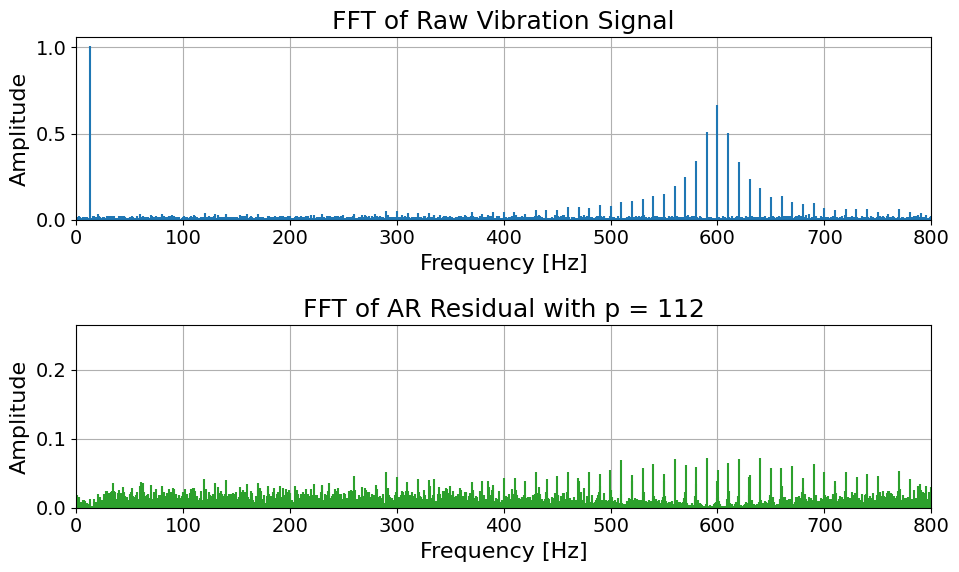

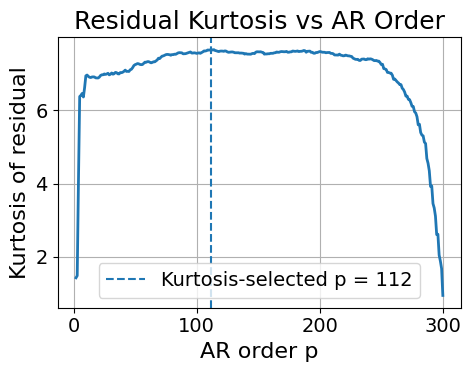

In [ ]:
# ============================================================
# AR filtering of bearing fault simulation signal
# vib and t are assumed to be already generated
# AR order is selected only by residual kurtosis criterion
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import yule_walker
from scipy.stats import kurtosis

# ------------------------------------------------------------
# 0) Basic settings
# ------------------------------------------------------------
x = vib.copy()

# Estimate sampling frequency from time vector t
fs = 1 / (t[1] - t[0])

# AR order candidates
p_max = 300
p_list = np.arange(2, p_max + 1)

kurt_vals = []

xp_dict = {}
res_dict = {}

# ------------------------------------------------------------
# 1) AR order sweep using residual kurtosis criterion
# ------------------------------------------------------------
for p in p_list:

    # Estimate AR coefficients using Yule-Walker
    rho, sigma = yule_walker(x, order=p, method="mle")

    # One-step AR prediction
    xp = np.zeros_like(x)

    for k in range(1, p + 1):
        xp[k:] += rho[k - 1] * x[:-k]

    # Residual signal
    res = x - xp

    # Exclude first p samples
    res_eff = res[p:]

    xp_dict[p] = xp
    res_dict[p] = res

    # Residual kurtosis
    kurt_val = kurtosis(res_eff, fisher=True, bias=False)
    kurt_vals.append(kurt_val)

kurt_vals = np.array(kurt_vals)

# ------------------------------------------------------------
# 2) Select AR order by maximum residual kurtosis
# ------------------------------------------------------------
p_kurt = p_list[np.argmax(kurt_vals)]

print(f"AR order selected by residual kurtosis criterion = {p_kurt}")

# Selected prediction and residual signals
xp_kurt = xp_dict[p_kurt]
res_kurt = res_dict[p_kurt]

# Effective residual for FFT
res_kurt_eff = res_kurt[p_kurt:]

# Kurtosis values for plot titles
raw_kurt = kurtosis(x, fisher=True, bias=False)
res_kurt_value = kurtosis(res_kurt_eff, fisher=True, bias=False)

# ------------------------------------------------------------
# 3) FFT (fft_oneside is already defined earlier in this notebook;
#    mean is removed here to drop the DC bin before computing magnitude)
# ------------------------------------------------------------
freq_raw, fft_raw = fft_oneside(x - np.mean(x), fs)
freq_kurt, fft_kurt = fft_oneside(res_kurt_eff - np.mean(res_kurt_eff), fs)

# Same y-axis limit for FFT comparison
freq_xlim = 800
idx_raw_xlim = freq_raw <= freq_xlim
fft_ylim = np.max(fft_raw[idx_raw_xlim]) * 1.05

# ------------------------------------------------------------
# 4) Time-domain comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x, linewidth=0.8)
plt.title(f"Raw Vibration Signal (Kurtosis = {raw_kurt:.3f})")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, res_kurt, linewidth=0.8)
plt.title(f"AR Residual with p = {p_kurt} (Kurtosis = {res_kurt_value:.3f})")
plt.xlabel("Time [s]")
plt.ylabel("Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) FFT comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Raw signal FFT
plt.subplot(2, 1, 1)
plt.stem(freq_raw, fft_raw, linefmt='C0-', markerfmt=' ', basefmt=' ')
plt.title("FFT of Raw Vibration Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, freq_xlim)
plt.ylim(0, fft_ylim)
plt.grid(True)

# Kurtosis-selected residual FFT
plt.subplot(2, 1, 2)
plt.stem(freq_kurt, fft_kurt, linefmt='C2-', markerfmt=' ', basefmt=' ')
plt.title(f"FFT of AR Residual with p = {p_kurt}")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, freq_xlim)
plt.ylim(0, fft_ylim/4)
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Residual kurtosis vs AR order
# ------------------------------------------------------------
plt.figure(figsize=(5,4))

plt.plot(p_list, kurt_vals, linewidth=2)
plt.axvline(p_kurt, linestyle='--', label=f"Kurtosis-selected p = {p_kurt}")
plt.title("Residual Kurtosis vs AR Order")
plt.xlabel("AR order p")
plt.ylabel("Kurtosis of residual")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## SK-BPF

### STFT of truncated sine wave

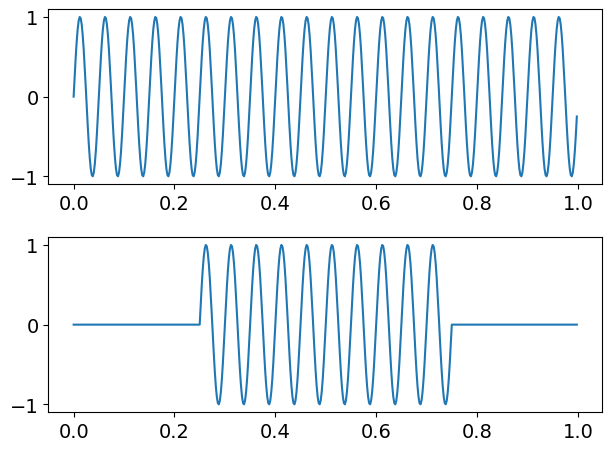

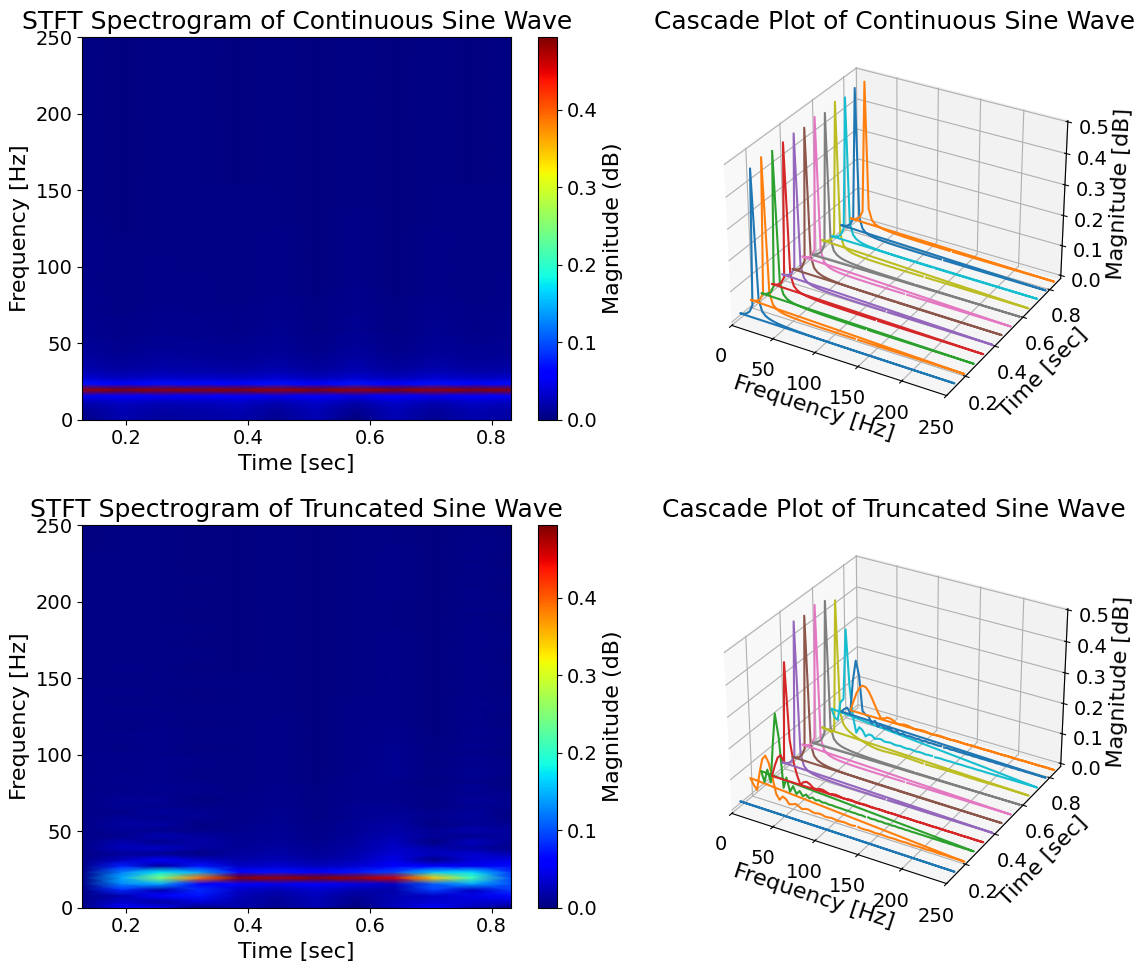

In [ ]:
# Import modules

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# (stft is defined in the "Settings and Utilities" section
#  at the top of this notebook)

fs = 500
T = 1
t = np.arange(0, T, 1/fs)
n = len(t)

p = 20

x1 = np.sin(2 * np.pi * p * t)

i1 = np.argmin(np.abs(t - 0.25))
i2 = np.argmin(np.abs(t - 0.75))

x2 = np.zeros_like(t)
x2[i1:i2] = np.sin(2 * np.pi * p * t[i1:i2])

plt.figure()

plt.subplot(211)
plt.plot(t, x1)
plt.subplot(212)
plt.plot(t, x2)
plt.tight_layout()
plt.show()

# Input : x (signal), fs, list of nperseg values to compare
# Output: STFT spectrograms computed at each requested resolution
def stft_cascade(x, fs, ax, step=1):
    nperseg = 128
    noverlap = nperseg * 3 // 4

    f, t, Zxx = signal.stft(x, fs, window='rect', nperseg=nperseg, noverlap=noverlap, nfft=nperseg, return_onesided=True, boundary=None, padded=False)

    Zxx = np.fft.fftshift(Zxx, axes=0)
    f = np.fft.fftshift(f)
    Zxx_mag = np.abs(Zxx)
    Zxx_db = 20 * np.log10(np.abs(Zxx) + 1e-10)

    # cascade plot: each time slice is plotted as one spectrum
    for i in range(0, len(t), step):
        ax.plot(f, np.full_like(f, t[i]), Zxx_mag[:, i])

    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Time [sec]')
    ax.set_zlabel('Magnitude [dB]')
    ax.set_xlim(0, fs/2)
    ax.set_title('STFT Cascade Plot')

fig = plt.figure(figsize=(12, 10))

# Spectrograms
ax1 = fig.add_subplot(221)
im1 = stft(x1, fs, ax1, shading='gouraud') # nearest or gouraud
ax1.set_title('STFT Spectrogram of Continuous Sine Wave')
plt.colorbar(im1, ax=ax1, label='Magnitude (dB)')

ax2 = fig.add_subplot(223)
im2 = stft(x2, fs, ax2, shading='gouraud')
ax2.set_title('STFT Spectrogram of Truncated Sine Wave')
plt.colorbar(im2, ax=ax2, label='Magnitude (dB)')

# Cascade plots
ax3 = fig.add_subplot(222, projection='3d')
stft_cascade(x1, fs, ax3)
ax3.set_title('Cascade Plot of Continuous Sine Wave')

ax4 = fig.add_subplot(224, projection='3d')
stft_cascade(x2, fs, ax4)
ax4.set_title('Cascade Plot of Truncated Sine Wave')

plt.tight_layout()
plt.show()


### SK-BPF of simulation signal

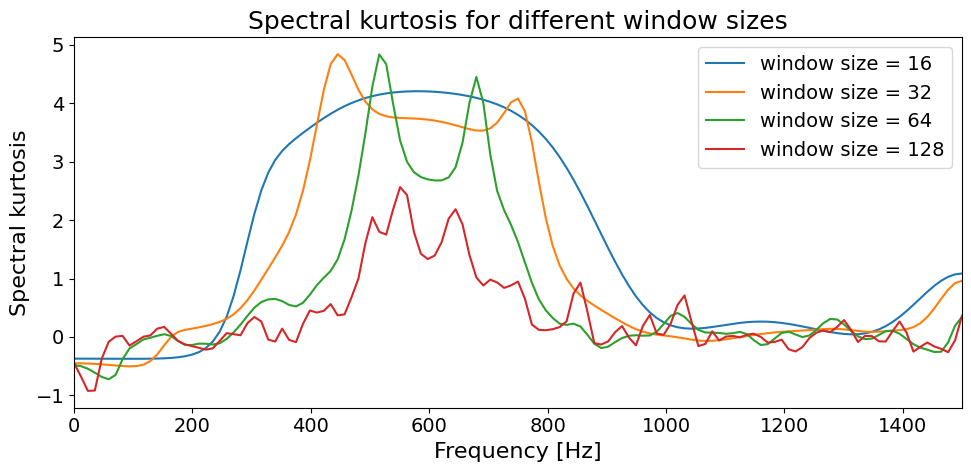

Combined SK-based band selection
--------------------------------
Center frequency  = 585.94 Hz
Bandwidth         = 234.38 Hz
Selected band     = [468.75, 703.12] Hz
Threshold ratio   = 0.80


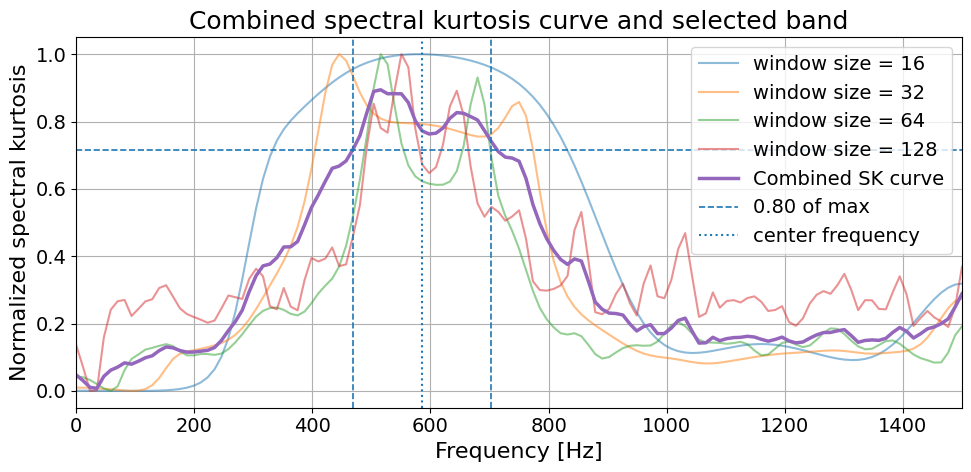

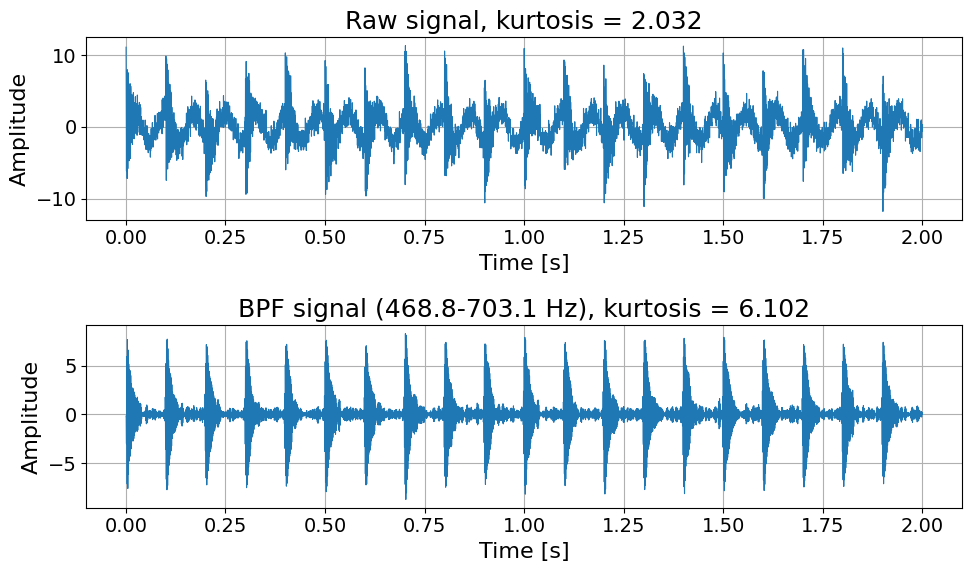

In [ ]:
# SK bandpass filtering + envelope analysis of simulation signal: old version

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window, butter, filtfilt, hilbert
from scipy.stats import kurtosis
from scipy.io import loadmat

# rawData = loadmat('/content/drive/MyDrive/PHM SUNYK/Datasets/Simulation_Bearing.mat')
# vib = rawData['vib'].flatten()
# t = rawData['t'].flatten()

# sampling frequency from time vector
dt = t[1] - t[0]
fs = 1 / dt

# ============================================================
# 5. Spectral kurtosis for SK band-pass filter design
# ============================================================
x = vib
N = len(x)

windLeng = np.array([2**4, 2**5, 2**6, 2**7])   # [16, 32, 64, 128]
numFreq = np.max(windLeng) + 1
specKurt = np.zeros((len(windLeng), numFreq))
lgd = []

for i, wlen in enumerate(windLeng):
    windFunc = get_window('hann', wlen)
    numOverlap = wlen // 2
    hop = wlen - numOverlap

    # complete windows only
    numWind = (N - wlen) // hop + 1
    STFT = np.zeros((numWind, numFreq))

    for idx in range(numWind):
        n_start = idx * hop
        seg = x[n_start:n_start + wlen] * windFunc

        stft_seg = np.fft.fft(seg, n=2 * (numFreq - 1))
        stft_mag = np.abs(stft_seg[:numFreq]) / wlen / np.sqrt(np.mean(windFunc**2)) * 2
        STFT[idx, :] = stft_mag

    for j in range(numFreq):
        m2 = np.mean(np.abs(STFT[:, j])**2)
        m4 = np.mean(np.abs(STFT[:, j])**4)
        specKurt[i, j] = m4 / (m2**2) - 2 if m2 > 0 else 0

    lgd.append(f'window size = {wlen}')

freq_sk = np.arange(numFreq) / (2 * (numFreq - 1)) * fs

plt.figure(figsize=(10, 5))
for i in range(len(windLeng)):
    plt.plot(freq_sk, specKurt[i, :], label=lgd[i])
plt.title('Spectral kurtosis for different window sizes')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Spectral kurtosis')
plt.xlim([0, fs / 2])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# ============================================================
# Combined SK curve and automatic band selection
# ============================================================

# Option 1: simple average
# combined_sk = np.mean(specKurt, axis=0)

# Option 2: normalized average
specKurt_norm = np.zeros_like(specKurt)

for i in range(specKurt.shape[0]):
    sk_i = specKurt[i, :].copy()
    sk_i = sk_i - np.min(sk_i)        # shift to nonnegative
    if np.max(sk_i) > 0:
        sk_i = sk_i / np.max(sk_i)   # normalize to max = 1
    specKurt_norm[i, :] = sk_i

combined_sk = np.mean(specKurt_norm, axis=0)

# Search only meaningful frequency range
min_search_freq = 10
max_search_freq = fs / 2

valid_idx = (freq_sk >= min_search_freq) & (freq_sk <= max_search_freq)

combined_search = combined_sk.copy()
combined_search[~valid_idx] = -np.inf

# Maximum point of combined SK curve
best_idx = np.argmax(combined_search)
best_freq = freq_sk[best_idx]
best_value = combined_sk[best_idx]

# Threshold rule: ratio of maximum
threshold_ratio = 0.8
threshold = threshold_ratio * best_value

above = combined_sk >= threshold

# Find contiguous region around the maximum point
left_idx = best_idx
while left_idx > 0 and above[left_idx - 1]:
    left_idx -= 1

right_idx = best_idx
while right_idx < len(above) - 1 and above[right_idx + 1]:
    right_idx += 1

f_low = freq_sk[left_idx]
f_high = freq_sk[right_idx]

center_freq = (f_low + f_high) / 2
bandwidth = f_high - f_low

freq_range = [f_low, f_high]

print("Combined SK-based band selection")
print("--------------------------------")
print(f"Center frequency  = {center_freq:.2f} Hz")
print(f"Bandwidth         = {bandwidth:.2f} Hz")
print(f"Selected band     = [{f_low:.2f}, {f_high:.2f}] Hz")
print(f"Threshold ratio   = {threshold_ratio:.2f}")

plt.figure(figsize=(10, 5))

for i, wlen in enumerate(windLeng):
    plt.plot(freq_sk, specKurt_norm[i, :], alpha=0.5, label=f'window size = {wlen}')

plt.plot(freq_sk, combined_sk, linewidth=2.5, label='Combined SK curve')

plt.axhline(threshold, linestyle='--', linewidth=1.2, label=f'{threshold_ratio:.2f} of max')
plt.axvline(f_low, linestyle='--', linewidth=1.2)
plt.axvline(f_high, linestyle='--', linewidth=1.2)
plt.axvline(center_freq, linestyle=':', linewidth=1.5, label='center frequency')

plt.title('Combined spectral kurtosis curve and selected band')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Normalized spectral kurtosis')
plt.xlim([0, fs / 2])
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# ============================================================
# 6. Band-pass filtering using selected SKBPF band
# ============================================================
# freq_range = [500, 700]   # manual selection

b_bp, a_bp = butter(2, np.array(freq_range) / (fs / 2), btype='bandpass')
X_bp = filtfilt(b_bp, a_bp, x)

# Kurtosis before and after BPF
raw_kurt = kurtosis(x, fisher=True, bias=False)
bpf_kurt = kurtosis(X_bp, fisher=True, bias=False)

plt.figure(figsize=(10, 6))

# Raw signal
plt.subplot(2, 1, 1)
plt.plot(t, x, linewidth=0.8)
plt.title(f'Raw signal, kurtosis = {raw_kurt:.3f}')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# BPF signal
plt.subplot(2, 1, 2)
plt.plot(t, X_bp, linewidth=0.8)
plt.title(f'BPF signal ({freq_range[0]:.1f}-{freq_range[1]:.1f} Hz), kurtosis = {bpf_kurt:.3f}')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()


## Envelope Analysis

### Envelope example of sine wave

In [ ]:
# Example of envelope analysis

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Parameters
Ac = 1; Am = 0.5; fm = 1; fc = 10   # try different Am = 0.5 & 1.5
fs = 50; T = 3

t = np.arange(1/fs, T + 1e-12, 1/fs)

# AM signal (original signal)
x = (Ac + Am*np.cos(2*np.pi*fm*t)) * np.cos(2*np.pi*fc*t)

# Envelope via analytic signal
a = hilbert(x)
aa = np.abs(a)

# Figure 1: time-domain (envelope + signal)
plt.figure(1)
plt.plot(t, aa, label='Envelope |hilbert(x)|')
plt.plot(t, x, 'g:', label='x(t)')
plt.axis([0, 3, -2, 2])
plt.xlabel('Time (s)')
plt.ylabel(r'$\mathit{A}_x(t)$')
plt.legend()
plt.tight_layout()

# (fft_oneside is already defined earlier in this notebook)

# Figure 2: spectrum of x(t)
f, Xmag = fft_oneside(x, fs)
plt.figure(2)
plt.stem(f, Xmag, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.title('Spectrum of x(t)')

# Figure 3: spectrum of envelope aa(t)
f, Amag = fft_oneside(aa, fs)
plt.figure(3)
plt.stem(f, Amag, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.xlim([0, 5])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.title('Spectrum of envelope |hilbert(x)|')

plt.show()


### Envelope of simulation signal

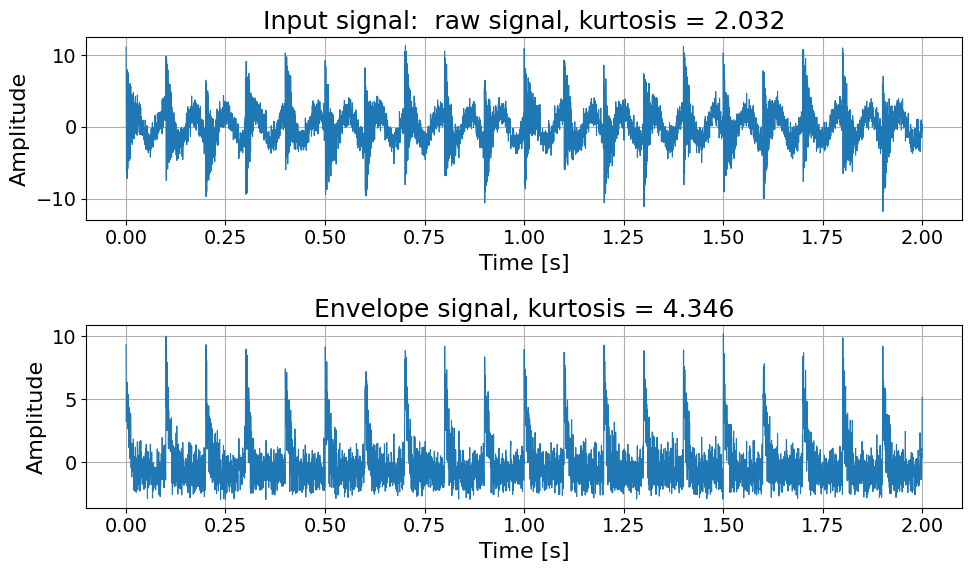

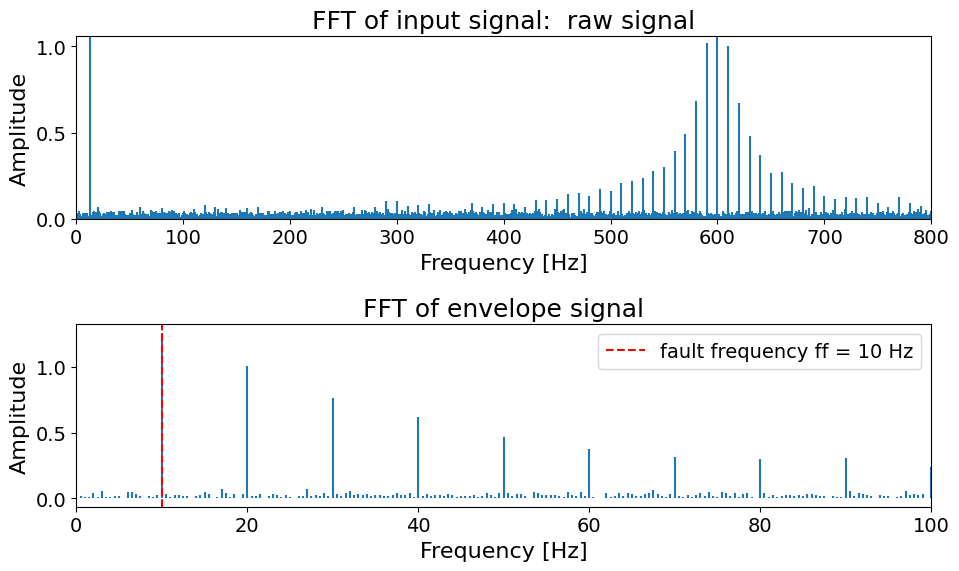

In [ ]:
# Envelope of simulation signal. Note the following.
# vib is original signal
# res_kurt is AR filtered residual signal
# X_bp is SKBPF signal

sig = vib; title = ' raw signal'
# sig = res_kurt; title = ' AR filtered residual'
# sig = X_bp; title = ' SK band-pass filtered signal'

sig_kurt = kurtosis(sig, fisher=True, bias=False)

analytic_sig = hilbert(sig)
envel = np.abs(analytic_sig)
envel = envel - np.mean(envel)
envel_kurt = kurtosis(envel, fisher=True, bias=False)

plt.figure(figsize=(10, 6))

# Raw signal
plt.subplot(2, 1, 1)
plt.plot(t, sig, linewidth=0.8)
plt.title(f'Input signal: {title}, kurtosis = {sig_kurt:.3f}')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Envelope signal
plt.subplot(2, 1, 2)
plt.plot(t, envel, linewidth=0.8)
plt.title(f'Envelope signal, kurtosis = {envel_kurt:.3f}')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

# input signal FFT
plt.subplot(2, 1, 1)
Nraw = len(sig)
fftRaw = np.abs(np.fft.fft(sig)) / Nraw * 2
freqRaw = np.arange(Nraw) / Nraw * fs
plt.stem(freqRaw[:Nraw//2], fftRaw[:Nraw//2], linefmt='C0-', markerfmt=' ', basefmt=' ')
plt.title(f'FFT of input signal: {title}')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim(0, freq_xlim)
plt.ylim(0, fft_ylim)
plt.tight_layout()

# envelope signal FFT
plt.subplot(2, 1, 2)
Ne = len(envel)
fftEnvel = np.abs(np.fft.rfft(envel)) / Ne * 2
fftEnvel[0] = fftEnvel[0] / 2
freq_env = np.fft.rfftfreq(Ne, d=1/fs)
plt.stem(freq_env, fftEnvel, linefmt='C0-', markerfmt=' ', basefmt=' ')
plt.axvline(ff, color='r', linestyle='--', label=f'fault frequency ff = {ff} Hz')
plt.title('FFT of envelope signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.xlim([0, max(100, ff * 10)])
plt.legend()
plt.tight_layout()
plt.show()

## KAU Bearing

### Read bearing data

In [ ]:
# Import modules

import gdown
import pandas as pd
from scipy import io
from scipy.stats import kurtosis
from scipy.signal import hilbert, lfilter, butter
from statsmodels.tsa.ar_model import AutoReg
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/PHM SUNYK/Datasets/Bearing_KAU/Innerrace_2.lvm"

data = pd.read_csv(path, sep='\t', header=None)
data = np.array(data)

# ========================== Test condition ===============================
fs = 51.2e3     # sampling frequency
fr = 1000 / 60  # Shaft speed [Hz]

# Only the ratio d/D and the number of balls Nb are known for this
# bearing (BPFI_mult + BPFO_mult = 11 exactly, and both give the same
# d/D*cos(alpha) = 0.19231), not their individual physical sizes.
# Since BPFO/BPFI/FTF depend only on the ratio d/D, any consistent
# pair works here; D=1.0 and d=0.19231 reproduce the known multipliers
# (BPFO=4.4423, BPFI=6.5577, FTF=0.4038) exactly. BSF is not used for
# this bearing, so its absolute accuracy here is not critical.
# (calc_bearing_fault_freq is defined in the "Settings and Utilities"
#  section at the top of this notebook)
fault_freqs = calc_bearing_fault_freq(D=1.0, d=0.19231, Nb=11, alpha=0.0, fr=fr)

bpfo, bpfi, ftf, bsf = fault_freqs
faultfreq = [bpfi, bpfo, fr]
failmode = {'BPFI', 'BPFO', 'Shaft'}

### Raw signal

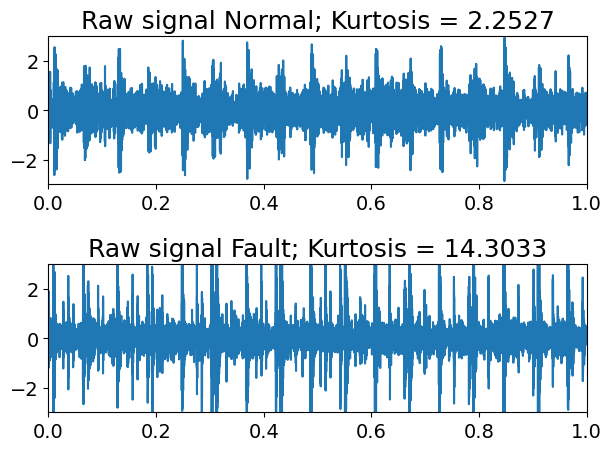

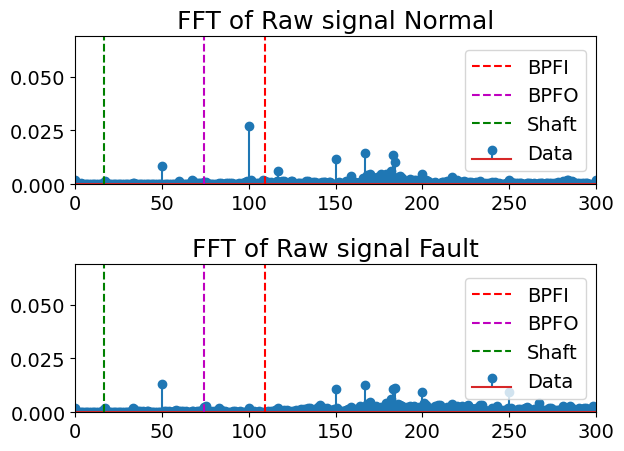

In [ ]:
# Raw signal

sig_normal = data[:, 3] # normal support bearing at sensor  3
sig_fault = data[:, 1] # faulty test bearing at sensor 1
t = data[:, 0] - data[0, 0] # time

N = len(sig_normal)

# (fft_oneside is already defined earlier in this notebook)
Freq, fft_normal = fft_oneside(sig_normal, fs)
_,    fft_fault = fft_oneside(sig_fault, fs)

plt.figure()
plt.subplot(211)
plt.plot(t, sig_normal)
plt.title(f'Raw signal Normal; Kurtosis = {kurtosis(sig_normal, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.subplot(212)
plt.plot(t, sig_fault)
plt.title(f'Raw signal Fault; Kurtosis = {kurtosis(sig_fault, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)
plt.tight_layout()

ymax = max(np.max(fft_normal), np.max(fft_fault))
ymax_plot = ymax * 1.1   # 10% margin

plt.figure()
plt.subplot(211)
plt.stem(Freq, fft_normal, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend(loc='center right')
plt.title('FFT of Raw signal Normal')

plt.subplot(212)
plt.stem(Freq, fft_fault, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend(loc='center right')
plt.title('FFT of Raw signal Fault')
plt.tight_layout()
plt.show()

### Raw signal envelope

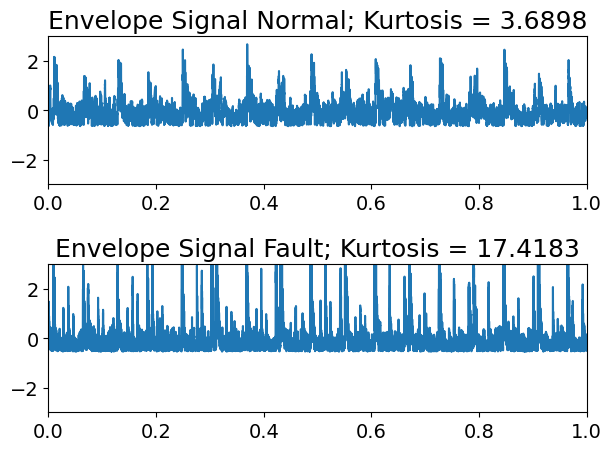

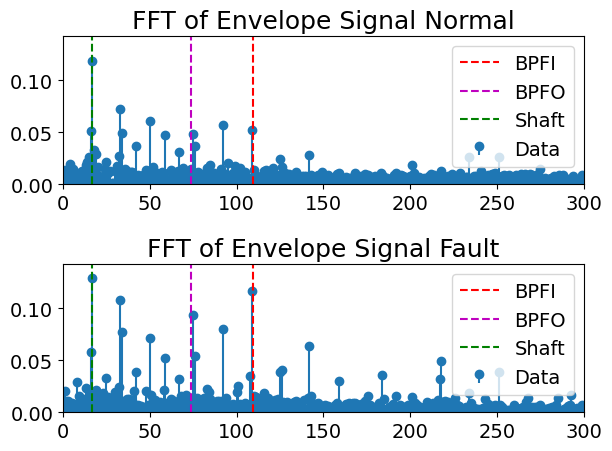

In [ ]:
#  Raw signal envelope

env_normal = np.abs(hilbert(sig_normal))
env_normal = env_normal - np.mean(env_normal)
env_fault = np.abs(hilbert(sig_fault))
env_fault = env_fault - np.mean(env_fault)

_, fft_env_normal = fft_oneside(env_normal, fs)
_, fft_env_fault = fft_oneside(env_fault, fs)

plt.figure()
plt.subplot(211)
plt.plot(t, env_normal)
plt.title(f'Envelope Signal Normal; Kurtosis = {kurtosis(env_normal, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.subplot(212)
plt.plot(t, env_fault)
plt.title(f'Envelope Signal Fault; Kurtosis = {kurtosis(env_fault, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)
plt.tight_layout()

ymax = max(np.max(fft_env_normal), np.max(fft_env_fault))
ymax_plot = ymax * 1.1   # 10% margin

plt.figure()
plt.subplot(211)
plt.stem(Freq, fft_env_normal, basefmt=' ', label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of Envelope Signal Normal')

plt.subplot(212)
plt.stem(Freq, fft_env_fault, basefmt=' ', label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of Envelope Signal Fault')
plt.tight_layout()
plt.show()

### AR filtering

100%|██████████| 28/28 [00:02<00:00, 11.53it/s]


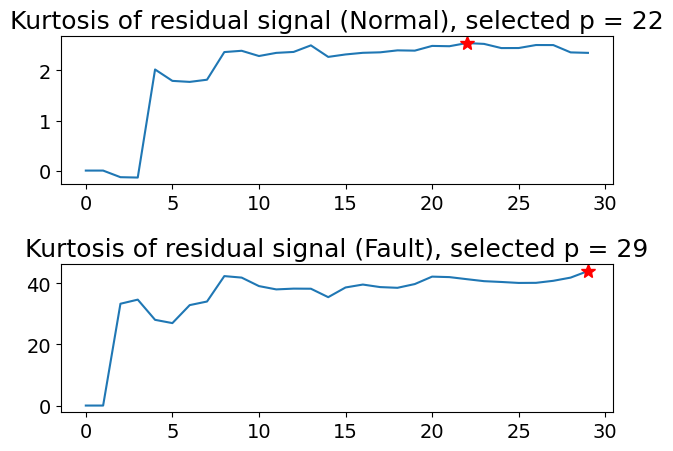

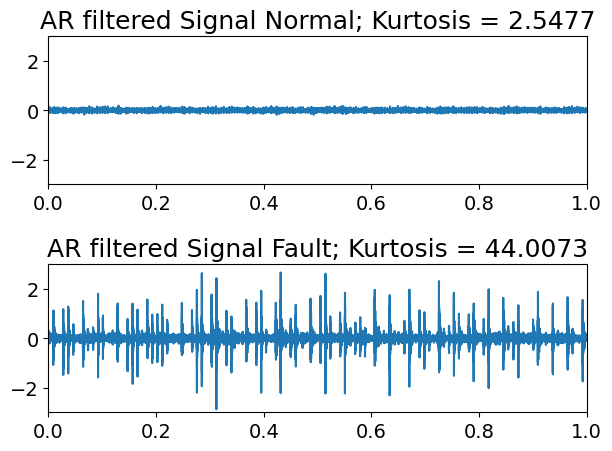

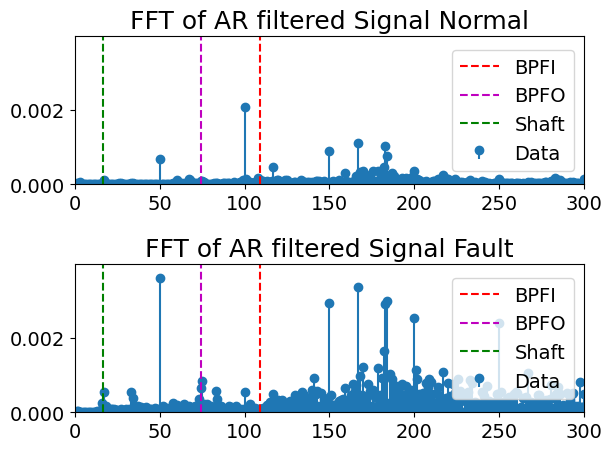

In [ ]:
# AR filtering of raw signal

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from statsmodels.tsa.ar_model import AutoReg
from tqdm import tqdm

# Input : x (signal), maxP (max/fixed AR order), find (0=search by kurtosis, else=fixed order)
# Output: xp_max (AR prediction), res_max (residual), kurt (kurtosis per order or None), max_kurt_p (selected AR order)
def aryule(x, maxP, find):
    n = len(x)

    if find == 0:
        kurt = np.zeros(maxP)
        for p in tqdm(range(2, maxP)):
            model = AutoReg(x, lags=p, old_names=False)
            results = model.fit()

            xp = results.predict(start=p, end=n-1)
            xp = np.concatenate([x[:p], xp])

            res = x - xp
            kurt[p] = kurtosis(res, fisher=True)

        max_kurt_p = np.argmax(kurt)

    else:
        max_kurt_p = maxP
        kurt = None

    model = AutoReg(x, lags=max_kurt_p, old_names=False)
    results = model.fit()

    xp_max = results.predict(start=max_kurt_p, end=n-1)
    xp_max = np.concatenate([x[:max_kurt_p], xp_max])

    res_max = x - xp_max

    return xp_max, res_max, kurt, max_kurt_p

maxP = 30   # original = 30
find = 0     # original = 0

ar_pred_normal, ar_res_normal, ar_kurt_normal, ar_order_normal = aryule(sig_normal, maxP, find)
ar_pred_fault, ar_res_fault, ar_kurt_fault, ar_order_fault = aryule(sig_fault, maxP, find)

# --------------------------------
# If find == 0: plot kurtosis-vs-p
# If find == 1: skip plot and print kurtosis only
# --------------------------------
if find == 0:
    plt.figure()
    plt.subplot(211)
    plt.plot(ar_kurt_normal)
    plt.plot(np.argmax(ar_kurt_normal), ar_kurt_normal[np.argmax(ar_kurt_normal)], 'r*', markersize=10)
    plt.title(f'Kurtosis of residual signal (Normal), selected p = {np.argmax(ar_kurt_normal)}')

    plt.subplot(212)
    plt.plot(ar_kurt_fault)
    plt.plot(np.argmax(ar_kurt_fault), ar_kurt_fault[np.argmax(ar_kurt_fault)], 'r*', markersize=10)
    plt.title(f'Kurtosis of residual signal (Fault), selected p = {np.argmax(ar_kurt_fault)}')

    plt.tight_layout()
    plt.show()

else:
    print(f'Fixed AR order used for normal signal : p = {ar_order_normal}')
    print(f'Residual kurtosis of normal signal    : {kurtosis(ar_res_normal, fisher=True):.4f}')
    print(f'Fixed AR order used for fault signal  : p = {ar_order_fault}')
    print(f'Residual kurtosis of fault signal     : {kurtosis(ar_res_fault, fisher=True):.4f}')


# FFT of residual signals (fft_oneside is already defined earlier in this notebook)
_, fft_ar_res_normal = fft_oneside(ar_res_normal, fs)
_, fft_ar_res_fault = fft_oneside(ar_res_fault, fs)


# Time-domain residual signals
plt.figure()
plt.subplot(211)
plt.plot(t, ar_res_normal)
plt.title(f'AR filtered Signal Normal; Kurtosis = {kurtosis(ar_res_normal, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.subplot(212)
plt.plot(t, ar_res_fault)
plt.title(f'AR filtered Signal Fault; Kurtosis = {kurtosis(ar_res_fault, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.tight_layout()
plt.show()

ymax = max(np.max(fft_ar_res_normal), np.max(fft_ar_res_fault))
ymax_plot = ymax * 1.1   # 10% margin

# Frequency-domain residual signals
plt.figure()
plt.subplot(211)
plt.stem(Freq, fft_ar_res_normal, basefmt=" ", label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend(loc='center right')
plt.title('FFT of AR filtered Signal Normal')

plt.subplot(212)
plt.stem(Freq, fft_ar_res_fault, basefmt=" ", label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend(loc='center right')
plt.title('FFT of AR filtered Signal Fault')

plt.tight_layout()
plt.show()

### AR filtering & envelope

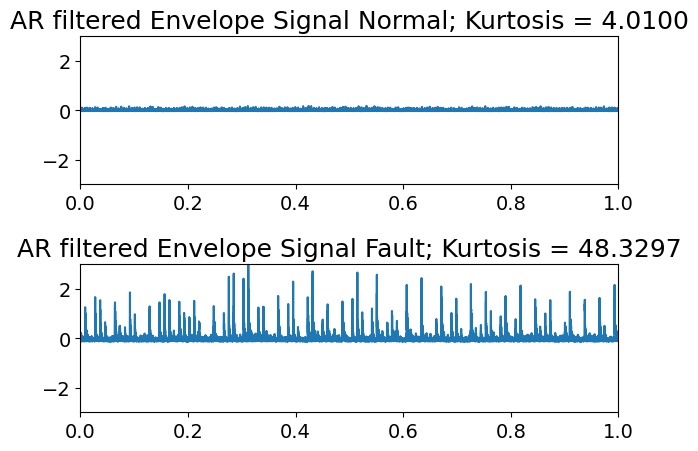

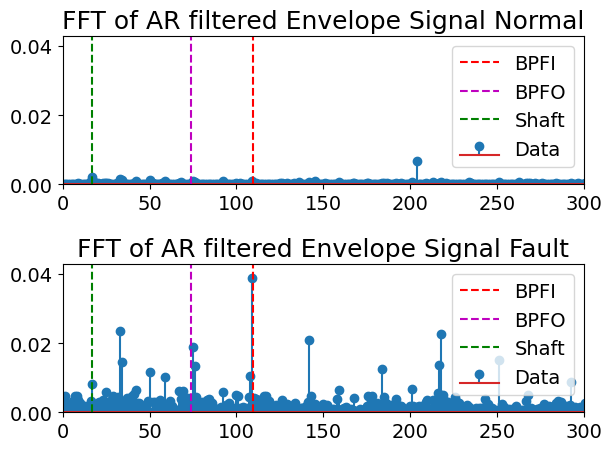

In [ ]:
# AR filtering and envelope

env_ar_normal = np.abs(hilbert(ar_res_normal))
env_ar_normal = env_ar_normal - np.mean(env_ar_normal)
env_ar_fault = np.abs(hilbert(ar_res_fault))
env_ar_fault = env_ar_fault - np.mean(env_ar_fault)

_, fft_env_ar_normal = fft_oneside(env_ar_normal, fs)
_, fft_env_ar_fault = fft_oneside(env_ar_fault, fs)

plt.figure()
plt.subplot(211)
plt.plot(t, env_ar_normal)
plt.title(f'AR filtered Envelope Signal Normal; Kurtosis = {kurtosis(env_ar_normal, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.subplot(212)
plt.plot(t, env_ar_fault)
plt.title(f'AR filtered Envelope Signal Fault; Kurtosis = {kurtosis(env_ar_fault, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)
plt.tight_layout()

ymax = max(np.max(fft_env_ar_normal), np.max(fft_env_ar_fault))
ymax_plot = ymax * 1.1   # 10% margin

plt.figure()
plt.subplot(211)
plt.stem(Freq, fft_env_ar_normal, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of AR filtered Envelope Signal Normal')

plt.subplot(212)
plt.stem(Freq, fft_env_ar_fault, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of AR filtered Envelope Signal Fault')
plt.tight_layout()
plt.show()

### function: fast_kurtogram & bandpass

In [ ]:
# ------------------------------------------------------------------------------
# kurtogram.py
#
# Implement the Fast Kurtogram Algorithm in Python
#
#
# Created: 09/21/2019 - Daniel Newman -- danielnewman09@gmail.com
#
# Modified:
#   * 09/21/2019 - DMN -- danielnewman09@gmail.com
#           - Replicated Jerome Antoni's Fast Kurtogram algorithm in Python
#             https://www.mathworks.com/matlabcentral/fileexchange/48912-fast-kurtogram
#
#
# ------------------------------------------------------------------------------

from scipy.signal import firwin
from scipy.signal import lfilter
import numpy as np


# Input : x (signal), nlevel (decomposition depth), Fs (sampling frequency)
# Output: Kurtogram matrix, best center frequency/bandwidth for the optimal filter band
def fast_kurtogram(x, fs, nlevel=7):
    N = x.flatten().size

    N2 = np.log2(N) - 7

    if nlevel > N2:
        raise ValueError('Please enter a smaller number of decomposition levels')

    x -= np.mean(x)

    N = 16
    fc = 0.4

    h = firwin(N + 1, fc) * np.exp(2j * np.pi * np.arange(N + 1) * 0.125)

    n = np.arange(2, N + 2)

    g = h[(1 - n) % N] * (-1.) ** (1 - n)

    N = int(np.fix(3 / 2 * N))

    h1 = firwin(N + 1, 2 / 3 * fc) * np.exp(2j * np.pi * np.arange(0, N + 1) * 0.25 / 3)
    h2 = h1 * np.exp(2j * np.pi * np.arange(0, N + 1) / 6)
    h3 = h1 * np.exp(2j * np.pi * np.arange(0, N + 1) / 3)

    Kwav = _K_wpQ(x, h, g, h1, h2, h3, nlevel, 'kurt2')
    Kwav = np.clip(Kwav, 0, np.inf)
    Level_w = np.arange(1, nlevel + 1)
    Level_w = np.vstack((Level_w,
                         Level_w + np.log2(3) - 1)).flatten()
    Level_w = np.sort(np.insert(Level_w, 0, 0)[:2 * nlevel])

    freq_w = fs * (np.arange(3 * 2 ** nlevel) / (3 * 2 ** (nlevel + 1)) + 1 / (3 * 2 ** (2 + nlevel)))

    max_level_index = np.argmax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)])
    max_kurt = np.amax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)])
    level_max = Level_w[max_level_index]

    bandwidth = fs * 2 ** (-(Level_w[max_level_index] + 1))

    J = np.argmax(Kwav[max_level_index, :])

    fi = (J) / 3 / 2 ** (nlevel + 1)
    fi = fi + fs * 2 ** (-2 - Level_w[max_level_index])

    fc = fs * fi

    c, _, _, _ = find_wav_kurt(x, h, g, h1, h2, h3, level_max, fi, 'kurt2', fs)

    return Kwav, Level_w, freq_w, c, np.amax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)]), bandwidth, level_max


# Input : x (signal), opt (kurtosis option/mode)
# Output: kurtosis value of x
def _kurt(this_x, opt):
    eps = 2.2204e-16

    if opt.lower() == 'kurt2':
        if np.all(this_x == 0):
            K = 0
            return K
        this_x -= np.mean(this_x)

        E = np.mean(np.abs(this_x) ** 2)

        if E < eps:
            K = 0
            return K
        K = np.mean(np.abs(this_x) ** 4) / E ** 2

        if np.all(np.isreal(this_x)):
            K -= 3
        else:
            K -= 2
    elif opt.lower() == 'kurt1':
        if np.all(this_x == 0):
            K = 0
            return K
        this_x -= np.mean(this_x)
        E = np.mean(np.abs(this_x))

        if E < eps:
            K = 0
            return K

        K = np.mean(np.abs(this_x) ** 2) / E ** 2

        if np.all(np.isreal(this_x)):
            K -= 1.57
        else:
            K -= 1.27
    return K


def _K_wpQ(x, h, g, h1, h2, h3, nlevel, opt, level=None):
    '''
    Computes the kurtosis K of the complete "binary-ternary" wavelet packet transform w of signal x,
    up to nlevel, using the lowpass and highpass filters h and g, respectively.
    The values in K are sorted according to the frequency decomposition.
    '''

    if level == None:
        level = nlevel

    x = x.flatten()
    L = np.floor(np.log2(x.size))
    x = np.atleast_2d(x).T

    KD, KQ = _K_wpQ_local(x, h, g, h1, h2, h3, nlevel, opt, level)

    K = np.zeros((2 * nlevel, 3 * 2 ** nlevel))

    K[0, :] = KD[0, :]

    for i in np.arange(1, nlevel):
        K[2 * i - 1, :] = KD[i, :]
        K[2 * i, :] = KQ[i - 1, :]

    K[2 * nlevel - 1, :] = KD[nlevel, :]

    return K


# Input : x, filter coefficients (h, g, h1, h2, h3), acoeff/bcoeff path, level
# Output: filtered signal coefficients at the given wavelet-packet node
def _K_wpQ_local(x, h, g, h1, h2, h3, nlevel, opt, level):
    a, d = _DBFB(x, h, g)

    N = np.amax(a.shape)

    d = d * (-1) ** (np.atleast_2d(np.arange(1, N + 1)).T)

    Lh = np.amax(h.shape)
    Lg = np.amax(g.shape)

    K1 = _kurt(a[Lh - 1:], opt)
    K2 = _kurt(d[Lg - 1:], opt)

    if level > 2:
        a1, a2, a3 = _TBFB(a, h1, h2, h3)
        d1, d2, d3 = _TBFB(d, h1, h2, h3)

        Ka1 = _kurt(a1[Lh - 1:], opt)
        Ka2 = _kurt(a2[Lh - 1:], opt)
        Ka3 = _kurt(a3[Lh - 1:], opt)
        Kd1 = _kurt(d1[Lh - 1:], opt)
        Kd2 = _kurt(d2[Lh - 1:], opt)
        Kd3 = _kurt(d3[Lh - 1:], opt)

    else:
        Ka1 = 0
        Ka2 = 0
        Ka3 = 0
        Kd1 = 0
        Kd2 = 0
        Kd3 = 0

    if level == 1:
        K = np.concatenate((K1 * np.ones(3), K2 * np.ones(3)))
        #         print(K.shape)
        KQ = np.array([Ka1, Ka2, Ka3, Kd1, Kd2, Kd3])

    if level > 1:
        Ka, KaQ = _K_wpQ_local(a, h, g, h1, h2, h3, nlevel, opt, level - 1)
        Kd, KdQ = _K_wpQ_local(d, h, g, h1, h2, h3, nlevel, opt, level - 1)

        K1 *= np.ones(np.amax(Ka.shape))
        K2 *= np.ones(np.amax(Kd.shape))

        K = np.vstack((np.concatenate([K1, K2]),
                       np.hstack((Ka, Kd))))

        Long = int(2 / 6 * np.amax(KaQ.shape))
        Ka1 *= np.ones(Long)
        Ka2 *= np.ones(Long)
        Ka3 *= np.ones(Long)
        Kd1 *= np.ones(Long)
        Kd2 *= np.ones(Long)
        Kd3 *= np.ones(Long)

        KQ = np.vstack((np.concatenate([Ka1, Ka2, Ka3, Kd1, Kd2, Kd3]),
                        np.hstack((KaQ, KdQ))))

    if level == nlevel:
        K1 = _kurt(x, opt)

        K = np.vstack((K1 * np.ones(np.amax(K.shape)), K))

        a1, a2, a3 = _TBFB(x, h1, h2, h3)

        Ka1 = _kurt(a1[Lh - 1:], opt)
        Ka2 = _kurt(a2[Lh - 1:], opt)
        Ka3 = _kurt(a3[Lh - 1:], opt)

        Long = int(1 / 3 * np.amax(KQ.shape))

        Ka1 *= np.ones(Long)
        Ka2 *= np.ones(Long)
        Ka3 *= np.ones(Long)

        KQ = np.vstack((np.concatenate([Ka1, Ka2, Ka3]),
                        KQ[:-2, :]))

    return K, KQ


# Input : x (signal), h1, h2, h3 (filter coefficients)
# Output: c1, c2, c3 (three-band filter bank outputs)
def _TBFB(x, h1, h2, h3):
    N = x.flatten().size

    a1 = lfilter(h1, 1, x.flatten())
    a1 = a1[2:N:3]
    a1 = np.atleast_2d(a1).T

    a2 = lfilter(h2, 1, x.flatten())
    a2 = a2[2:N:3]
    a2 = np.atleast_2d(a2).T

    a3 = lfilter(h3, 1, x.flatten())
    a3 = a3[2:N:3]
    a3 = np.atleast_2d(a3).T

    return a1, a2, a3


# Input : x (signal), h, g (filter coefficients)
# Output: a (approximation), d (detail) after two-band filter bank decomposition
def _DBFB(x, h, g):
    N = x.flatten().size

    a = lfilter(h, 1, x.flatten())
    a = a[1:N:2]
    a = np.atleast_2d(a).T

    d = lfilter(g, 1, x.flatten())

    d = d[1:N:2]

    d = np.atleast_2d(d).T

    return a, d


# Input : i (index), l (number of bits/levels)
# Output: binary representation of i as an array of length l
def binary(i, k):
    k = int(k)

    if i > 2 ** k:
        raise ValueError('i must be such that i < 2^k')

    a = np.zeros(k)

    temp = i

    for l in np.arange(k)[::-1]:
        a[-(l + 1)] = np.fix(temp / 2 ** l)
        temp -= a[-(l + 1)] * 2 ** l

    return a


# Input : x, h, g, h1, h2, h3 (filter coefficients), nlevel, level, freq_w, opt
# Output: filtered coefficients, bandwidth, center frequency, node index for max kurtosis
def find_wav_kurt(x, h, g, h1, h2, h3, Sc, Fr, opt, Fs):
    level = np.fix(Sc) + (np.remainder(Sc, 1) >= 0.5) * (np.log2(3) - 1)

    Bw = 2 ** (-level - 1)
    freq_w = np.arange(2 ** level) / (2 ** (level + 1)) + Bw / 2
    J = np.argmin(np.abs(freq_w - Fr))
    fc = freq_w[J]
    i = np.round((fc / Bw - 1 / 2))

    if np.remainder(level, 1) == 0:

        acoeff = binary(i, level)
        bcoeff = np.array([])
        temp_level = level

    else:

        i2 = np.fix(i / 3)
        temp_level = np.fix(level) - 1
        acoeff = binary(i2, temp_level)
        bcoeff = i - i2 * 3

    acoeff = acoeff[::-1]

    c = K_wpQ_filt(x, h, g, h1, h2, h3, acoeff, bcoeff, temp_level)

    kx = _kurt(c, opt)

    sig = np.median(np.abs(c)) / np.sqrt(np.pi / 2)

    threshold = sig * np.sqrt((-2 * 1 ** 2) * np.log(1 - 0.999))

    return c, Bw, fc, i


# Input : x (signal), filter coefficients (h,g,h1,h2,h3), acoeff/bcoeff path, level
# Output: c (wavelet-packet filtered coefficients)
def K_wpQ_filt(x, h, g, h1, h2, h3, acoeff, bcoeff, level=None):
    nlevel = acoeff.size

    L = np.floor(np.log2(np.amax(x.shape)))

    if level == None:
        if nlevel >= L:
            raise ValueError('nlevel must be smaller')

        level = nlevel

    x = np.atleast_2d(x.flatten()).T

    if nlevel == 0:
        if bcoeff.size == 0:
            c = x
        else:
            c1, c2, c3 = _TBFB(x, h1, h2, h3)

            if bcoeff == 0:
                c = c1[h1.size - 1:]
            elif bcoeff == 1:
                c = c2[h2.size - 1:]
            elif bcoeff == 2:
                c = c3[h3.size - 1:]

    else:

        c = K_wpQ_filt_local(x, h, g, h1, h2, h3, acoeff, bcoeff, level)

    return c


# Input : same as K_wpQ_filt, used internally for recursive filtering
# Output: c (filtered coefficients at the given decomposition level)
def K_wpQ_filt_local(x, h, g, h1, h2, h3, acoeff, bcoeff, level):
    a, d = _DBFB(x, h, g)

    N = a.size

    level = int(level)

    d = d * np.array([(-1) ** (np.arange(1, N + 1))]).T

    if level == 1:
        if bcoeff.size == 0:
            if acoeff[level - 1] == 0:
                c = a[h.size - 1:]
            else:
                c = d[g.size - 1:]
        else:
            if acoeff[level - 1] == 0:
                c1, c2, c3 = _TBFB(a, h1, h2, h3)
            else:
                c1, c2, c3 = _TBFB(d, h1, h2, h3)

            if bcoeff == 0:
                c = c1[h1.size - 1:]
            elif bcoeff == 1:
                c = c2[h2.size - 1:]
            elif bcoeff == 2:
                c = c3[h3.size - 1:]

    if level > 1:
        if acoeff[level - 1] == 0:
            c = K_wpQ_filt_local(a, h, g, h1, h2, h3, acoeff, bcoeff, level - 1)
        else:
            c = K_wpQ_filt_local(d, h, g, h1, h2, h3, acoeff, bcoeff, level - 1)

    return c

# Input : data (signal), lowcut, highcut (Hz), fs (sampling frequency), order
# Output: y (band-pass filtered signal)
def bandpass(data, lowcut, highcut, fs, order):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], 'bandpass')
    y = lfilter(b, a, data, axis=0)
    return y


### Find band by Kurtogram

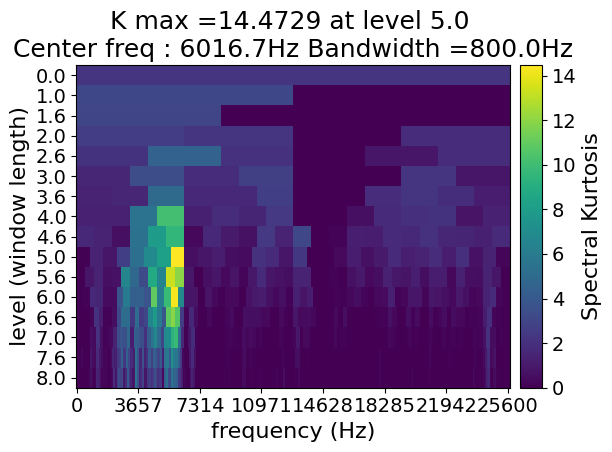

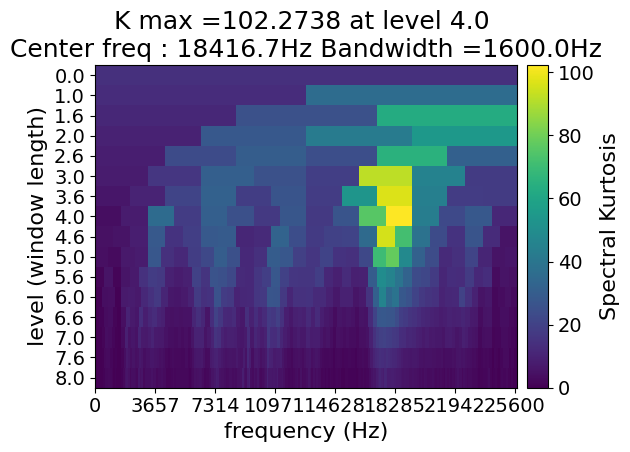

In [ ]:
import mpl_toolkits.axes_grid1

# Kurtogram of sig_normal to obtain center_freq_normal, bandwidth_normal
kurtogram_matrix, level_axis, freq_axis, c, max_kurt, bandwidth_normal, best_level = fast_kurtogram(sig_normal, fs, nlevel=8)     # Center frequency & bandwidth obtained from kurtogram
level_idx = np.where(level_axis == best_level)[0][0]
freq_idx = np.where(kurtogram_matrix[level_idx, :] == max_kurt)[0][0]
center_freq_raw = freq_axis[freq_idx]
ax = plt.gca()
im = ax.imshow(kurtogram_matrix, interpolation='none', aspect='auto')
freq_ticks = np.array(np.arange(0, fs/2+fs/2/7, fs/2/7), dtype=int)
plt.xticks(np.arange(0, kurtogram_matrix.shape[1], kurtogram_matrix.shape[1] // 7), labels=freq_ticks)
plt.title(f'K max ={max_kurt:.4f} at level {best_level:.1f} '
          f'\nCenter freq : {center_freq_raw + bandwidth_normal/2:.1f}Hz Bandwidth ={bandwidth_normal:.1f}Hz')
plt.xlabel('frequency (Hz)')
plt.yticks(np.arange(0, kurtogram_matrix.shape[0], 1), labels=np.round(level_axis, 1))
plt.ylabel('level (window length)')
divider = mpl_toolkits.axes_grid1.make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
plt.ylabel('Spectral Kurtosis')
plt.tight_layout()
plt.show()
center_freq_normal = center_freq_raw + bandwidth_normal/2

# Kurtogram of sig_fault to obtain center_freq_fault, bandwidth_fault
kurtogram_matrix, level_axis, freq_axis, c, max_kurt, bandwidth_fault, best_level = fast_kurtogram(sig_fault, fs, nlevel=8)     # Center frequency & bandwidth obtained from kurtogram
level_idx = np.where(level_axis == best_level)[0][0]
freq_idx = np.where(kurtogram_matrix[level_idx, :] == max_kurt)[0][0]
center_freq_raw = freq_axis[freq_idx]
ax = plt.gca()
im = ax.imshow(kurtogram_matrix, interpolation='none', aspect='auto')
freq_ticks = np.array(np.arange(0, fs/2+fs/2/7, fs/2/7), dtype=int)
plt.xticks(np.arange(0, kurtogram_matrix.shape[1], kurtogram_matrix.shape[1] // 7), labels=freq_ticks)
plt.title(f'K max ={max_kurt:.4f} at level {best_level:.1f} '
          f'\nCenter freq : {center_freq_raw + bandwidth_fault/2:.1f}Hz Bandwidth ={bandwidth_fault:.1f}Hz')
plt.xlabel('frequency (Hz)')
plt.yticks(np.arange(0, kurtogram_matrix.shape[0], 1), labels=np.round(level_axis, 1))
plt.ylabel('level (window length)')
divider = mpl_toolkits.axes_grid1.make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax)
plt.ylabel('Spectral Kurtosis')
plt.tight_layout()
plt.show()
center_freq_fault = center_freq_raw + bandwidth_fault/2


### BP filtering

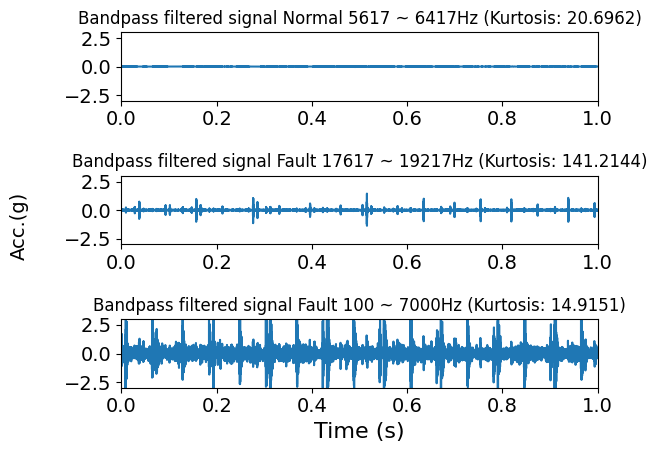

In [ ]:
bpf_normal = bandpass(sig_normal, center_freq_normal-bandwidth_normal/2, center_freq_normal+bandwidth_normal/2, fs, 4)
bpf_kurt_normal = kurtosis(bpf_normal, fisher=True)

bpf_fault = bandpass(sig_fault, center_freq_fault-bandwidth_fault/2, center_freq_fault+bandwidth_fault/2, fs, 4)
bpf_kurt_fault = kurtosis(bpf_fault, fisher=True)

bpf_fault_wide = bandpass(sig_fault, 100, 7000, fs, 4)
bpf_kurt_fault_wide = kurtosis(bpf_fault_wide, fisher=True)

# Time domain signal
fig = plt.figure()
plt.subplot(311); plt.plot(t, bpf_normal);
plt.xlim(0,1)
plt.ylim(-3, 3)
plt.title(f'Bandpass filtered signal Normal {center_freq_normal-bandwidth_normal/2:.0f} ~ {center_freq_normal+bandwidth_normal/2:.0f}Hz (Kurtosis: {bpf_kurt_normal:.4f})',fontsize=12)

plt.subplot(312); plt.plot(t, bpf_fault);
plt.xlim(0,1)
plt.ylim(-3, 3)
plt.title(f'Bandpass filtered signal Fault {center_freq_fault-bandwidth_fault/2:.0f} ~ {center_freq_fault+bandwidth_fault/2:.0f}Hz (Kurtosis: {bpf_kurt_fault:.4f})',fontsize=12)

plt.subplot(313)
plt.plot(t, bpf_fault_wide)
plt.xlim(0,1)
plt.ylim(-3, 3)
plt.title(f'Bandpass filtered signal Fault 100 ~ 7000Hz (Kurtosis: {bpf_kurt_fault_wide:.4f})',fontsize=12)
plt.xlabel('Time (s)'); fig.supylabel('Acc.(g)', size=14)
plt.tight_layout()
plt.show()

### BP filtering & envelope

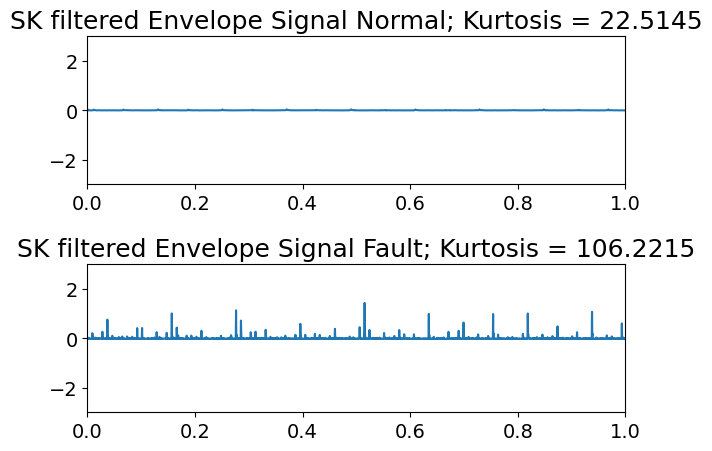

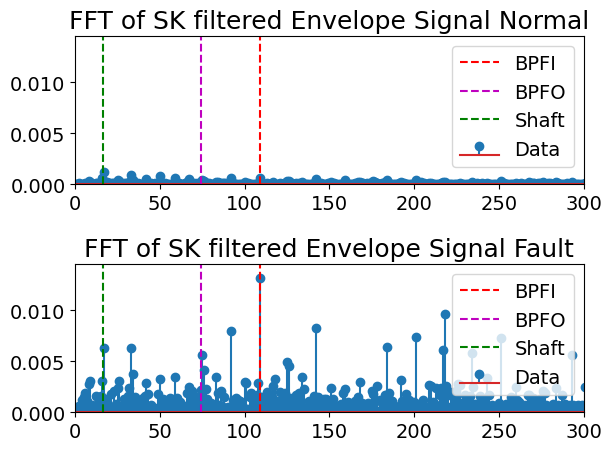

In [ ]:
# Envelope
env_sk_normal = np.abs(hilbert(bpf_normal))
env_sk_normal = env_sk_normal - np.mean(env_sk_normal)
env_sk_fault = np.abs(hilbert(bpf_fault))
env_sk_fault = env_sk_fault - np.mean(env_sk_fault)

# (fft_oneside is already defined earlier in this notebook)
Freq, fft_env_sk_normal = fft_oneside(env_sk_normal, fs)
_,    fft_env_sk_fault = fft_oneside(env_sk_fault, fs)

plt.figure()
plt.subplot(211)
plt.plot(t, env_sk_normal)
plt.title(f'SK filtered Envelope Signal Normal; Kurtosis = {kurtosis(env_sk_normal, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)

plt.subplot(212)
plt.plot(t, env_sk_fault)
plt.title(f'SK filtered Envelope Signal Fault; Kurtosis = {kurtosis(env_sk_fault, fisher=True):.4f}')
plt.xlim(0, 1)
plt.ylim(-3, 3)
plt.tight_layout()

ymax = max(np.max(fft_env_sk_normal), np.max(fft_env_sk_fault))
ymax_plot = ymax * 1.1   # 10% margin

plt.figure()
plt.subplot(211)
plt.stem(Freq, fft_env_sk_normal, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of SK filtered Envelope Signal Normal')

plt.subplot(212)
plt.stem(Freq, fft_env_sk_fault, basefmt=None, label='Data')
plt.axvline(faultfreq[0], c='r', linestyle='--', label='BPFI')
plt.axvline(faultfreq[1], c='m', linestyle='--', label='BPFO')
plt.axvline(faultfreq[2], c='g', linestyle='--', label='Shaft')
plt.xlim(0, 300)
plt.ylim(0, ymax_plot)
plt.legend()
plt.title('FFT of SK filtered Envelope Signal Fault')
plt.tight_layout()
plt.show()

## Resampling & TSA

### resampling & order analysis

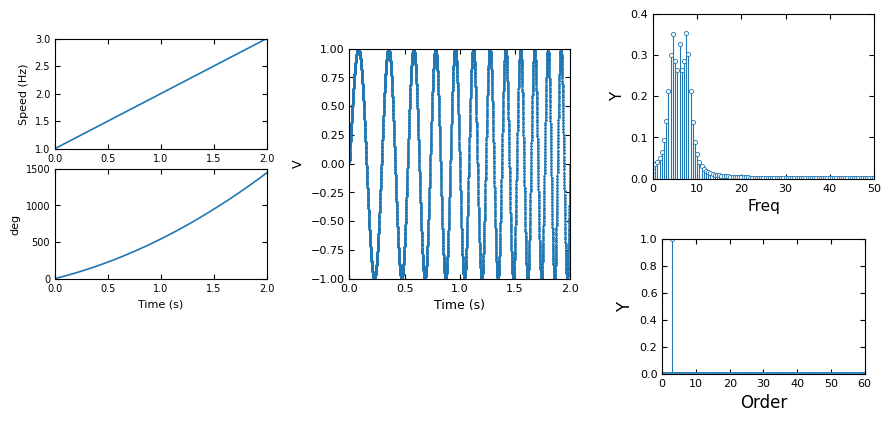

Final speed at t=2 s: 2.9995 Hz
Final angle at t=2 s: 1439.82 deg
Peak order should appear near: 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.patches import Polygon

# -----------------------------
# 1) Signal definition
# -----------------------------
fs = 2000
T = 2.0
t = np.arange(0, T, 1/fs)

# Shaft speed: 1 -> 3 Hz
f_rot = 1 + t

# Shaft angle [rad]
theta = 2 * np.pi * np.cumsum(f_rot) / fs
theta_deg = np.rad2deg(theta)

# IMPORTANT:
# To obtain ~12 cycles over 2 s while shaft speed averages 2 Hz,
# the signal must be 3X order, not 1X.
order_true = 3
x = np.sin(order_true * theta)

# -----------------------------
# 2) Time-domain FFT
# -----------------------------
N = len(x)
freq = np.fft.rfftfreq(N, d=1/fs)
Xf = np.abs(np.fft.rfft(x)) / N
Xf[1:-1] *= 2

# -----------------------------
# 3) Order analysis
# -----------------------------
samples_per_rev = 360
theta_uniform = np.arange(theta[0], theta[-1], 2*np.pi/samples_per_rev)

f_interp = interp1d(theta, x, kind='linear', fill_value='extrapolate')
x_order = f_interp(theta_uniform)

N2 = len(x_order)
order = np.fft.rfftfreq(N2, d=1/samples_per_rev)
Xo = np.abs(np.fft.rfft(x_order)) / N2
Xo[1:-1] *= 2

# -----------------------------
# 4) Plot layout similar to your figure
# -----------------------------
fig = plt.figure(figsize=(9.2, 5.0))

# left-top: speed
ax1 = fig.add_axes([0.07, 0.63, 0.23, 0.22])
ax1.plot(t, f_rot, lw=1.2)
ax1.set_xlim(0, 2)
ax1.set_ylim(1, 3)
ax1.set_xlabel('Time (s)', fontsize=8)
ax1.set_ylabel('Speed (Hz)', fontsize=8)
ax1.tick_params(labelsize=7, direction='in', top=True, right=True)

# left-bottom: angle
ax2 = fig.add_axes([0.07, 0.37, 0.23, 0.22])
ax2.plot(t, theta_deg, lw=1.2)
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 1500)
ax2.set_xlabel('Time (s)', fontsize=8)
ax2.set_ylabel('deg', fontsize=8)
ax2.tick_params(labelsize=7, direction='in', top=True, right=True)

# middle: waveform
ax3 = fig.add_axes([0.39, 0.37, 0.24, 0.46])
ax3.plot(t, x, 'o-', ms=1.0, lw=0.6)
ax3.set_xlim(0, 2)
ax3.set_ylim(-1, 1)
ax3.set_xlabel('Time (s)', fontsize=9)
ax3.set_ylabel('V', fontsize=9)
ax3.tick_params(labelsize=8, direction='in', top=True, right=True)

# right-top: frequency spectrum
ax4 = fig.add_axes([0.72, 0.57, 0.24, 0.33])
m1, s1, b1 = ax4.stem(freq, Xf, linefmt='C0-', markerfmt='C0o', basefmt=' ')
plt.setp(m1, markersize=3, markerfacecolor='white', markeredgewidth=0.6)
plt.setp(s1, linewidth=0.8)
ax4.set_xlim(0, 50)
ax4.set_ylim(0, 0.4)
ax4.set_xlabel('Freq', fontsize=11)
ax4.set_ylabel('Y', fontsize=11)
ax4.tick_params(labelsize=8, direction='in', top=True, right=True)

# right-bottom: order spectrum
ax5 = fig.add_axes([0.73, 0.18, 0.22, 0.27])
m2, s2, b2 = ax5.stem(order, Xo, linefmt='C0-', markerfmt='C0o', basefmt=' ')
plt.setp(m2, markersize=3, markerfacecolor='white', markeredgewidth=0.6)
plt.setp(s2, linewidth=0.8)
ax5.set_xlim(0, 60)
ax5.set_ylim(0, 1.0)
ax5.set_xlabel('Order', fontsize=12)
ax5.set_ylabel('Y', fontsize=12)
ax5.tick_params(labelsize=8, direction='in', top=True, right=True)

plt.show()

print(f'Final speed at t=2 s: {f_rot[-1]:.4f} Hz')
print(f'Final angle at t=2 s: {theta_deg[-1]:.2f} deg')
print(f'Peak order should appear near: {order_true}')

### TSA

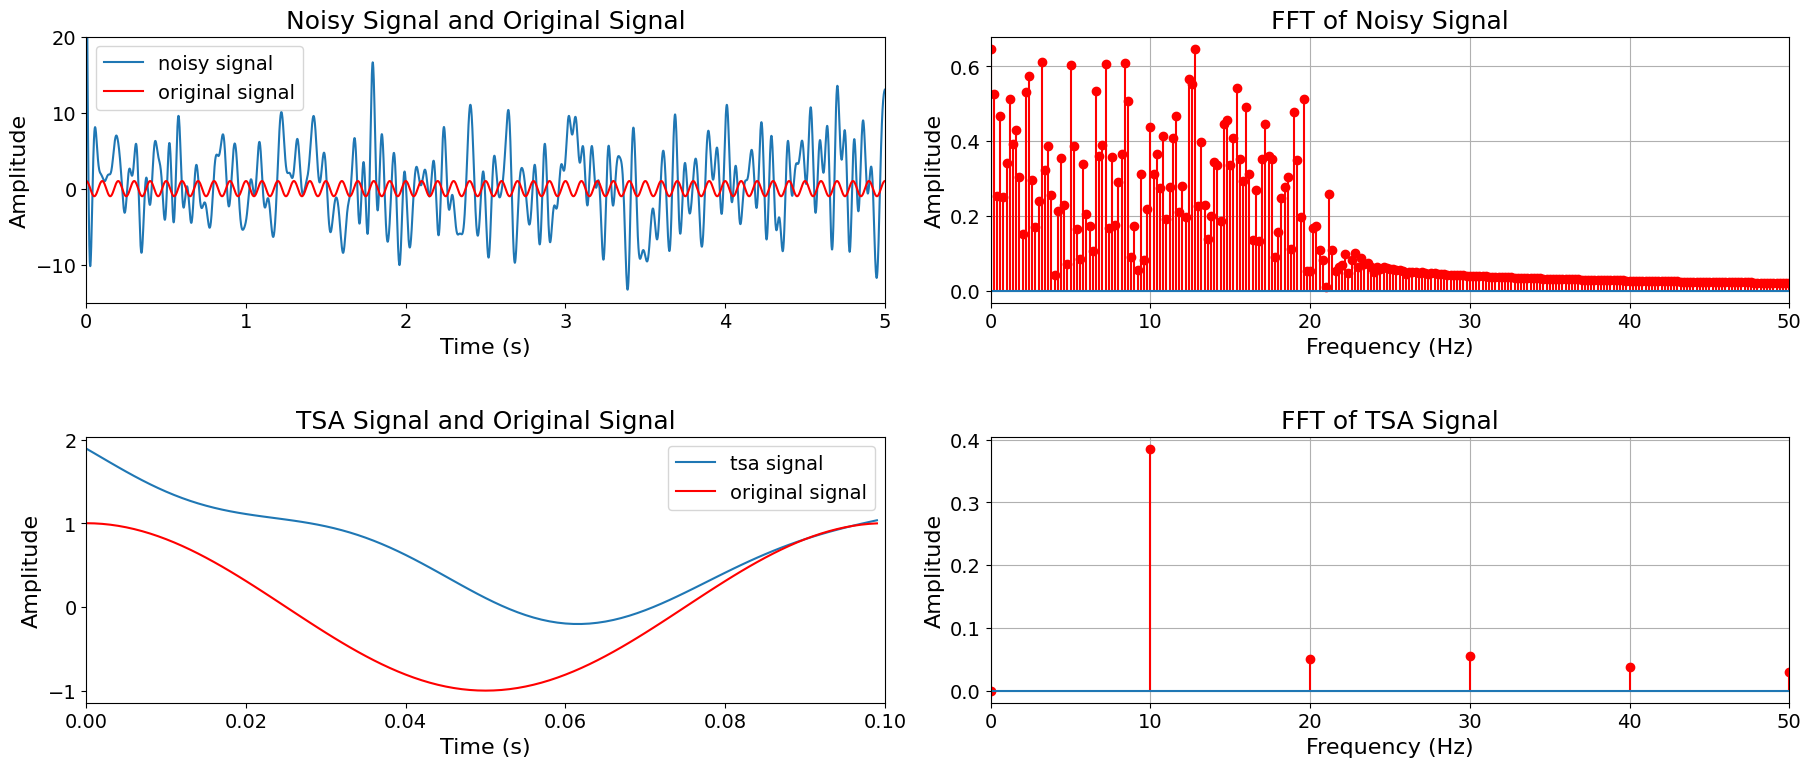

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d

# Define parameters
p = 10
Tp = 1 / p
fs = 1000
T = 50 * Tp
fac = 5

# Set global font sizes
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Generate time vector and original signal
t = np.arange(0, T, 1 / fs)
N = len(t)
x0 = np.cos(2 * np.pi * p * t)

# Generate broadband white noise and limit its bandwidth
np.random.seed(1)
nw = np.random.randn(N)
fc = 20
b, a = butter(9, fc / (fs / 2))
nw = filtfilt(b, a, nw)
nw = fac * np.sqrt(2) * (np.std(x0) / np.std(nw)) * nw

# Create noisy signal
x = x0 + nw

# Define TSA function
# Input : x (signal), fs (sampling frequency), Tp (assumed fixed rotation period)
# Output: ta (time synchronous averaged signal), t_resampled (time axis)
# NOTE: simplified version that assumes a known, fixed period (no tachometer needed)
def tsa(x, fs, Tp):
    t = np.arange(0, len(x) / fs, 1 / fs)

    T_rev = np.arange(0, t[-1], Tp)
    nrev = len(T_rev) - 1

    N_rev = int(round(Tp * fs))
    resample = np.empty((nrev, N_rev))

    for j in range(nrev):
        tmp = np.linspace(T_rev[j], T_rev[j + 1], N_rev, endpoint=False)
        resample[j, :] = tmp

    resx = interp1d(t, x, bounds_error=False, fill_value="extrapolate")(resample)
    ta = np.mean(resx, axis=0)
    t_resampled = np.linspace(0, Tp, N_rev, endpoint=False)

    return ta, t_resampled

# Apply TSA
xa, t_resampled = tsa(x, fs, Tp)
Na = len(xa)

# Compute FFT of noisy signal
X = np.fft.fft(x)
f = np.arange(0, fs, fs / N)

# Compute FFT of TSA signal
Xa = np.fft.fft(xa)
fa = np.arange(0, fs, fs / Na)

# Create 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(18, 8), constrained_layout=True)

# Top-left: noisy signal and original signal
axs[0, 0].plot(t, x, label='noisy signal')
axs[0, 0].plot(t, x0, 'r', label='original signal')
axs[0, 0].legend()
axs[0, 0].set_xlim([0, T])
axs[0, 0].set_ylim([-15, 20])
axs[0, 0].set_title('Noisy Signal and Original Signal')
axs[0, 0].set_xlabel('Time (s)')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].set_box_aspect(1 / 3)

# Top-right: FFT of noisy signal
axs[0, 1].stem(f[:N // 2], np.abs(X[:N // 2]) / (fs * T), markerfmt='ro', linefmt='r-', basefmt='')
axs[0, 1].set_xlim([0, 50])
axs[0, 1].grid()
axs[0, 1].set_title('FFT of Noisy Signal')
axs[0, 1].set_xlabel('Frequency (Hz)')
axs[0, 1].set_ylabel('Amplitude')
axs[0, 1].set_box_aspect(1 / 3)

# Bottom-left: TSA signal and original signal
axs[1, 0].plot(t_resampled, xa, label='tsa signal')
axs[1, 0].plot(t_resampled, np.cos(2 * np.pi * p * t_resampled), 'r', label='original signal')
axs[1, 0].legend()
axs[1, 0].set_xlim([0, Tp])
axs[1, 0].set_title('TSA Signal and Original Signal')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Amplitude')
axs[1, 0].set_box_aspect(1 / 3)

# Bottom-right: FFT of TSA signal
amp = np.abs(Xa[:Na // 2]) / (fs * Tp)
amp[0] = 0

axs[1, 1].stem(fa[:Na // 2], amp, markerfmt='ro', linefmt='r-', basefmt='')
axs[1, 1].set_xlim([0, 50])
axs[1, 1].grid()
axs[1, 1].set_title('FFT of TSA Signal')
axs[1, 1].set_xlabel('Frequency (Hz)')
axs[1, 1].set_ylabel('Amplitude')
axs[1, 1].set_box_aspect(1 / 3)

plt.show()

### TSA in order domain

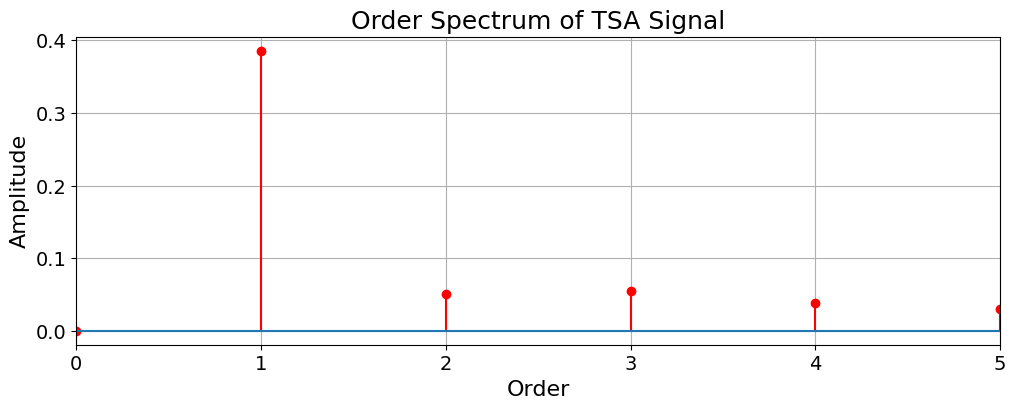

In [ ]:
# Result is plotted in order domain

# Convert frequency to order by normalizing with the shaft frequency p
# where fa contains frequency values in TSA spectrum
order = fa / p

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_box_aspect(1/3)

amp = np.abs(Xa[:Na // 2]) / (fs * Tp)
amp[0] = 0

ax.stem(order[:Na//2], amp, markerfmt='ro', linefmt='r-', basefmt='')
ax.set_xlim([0, 5])
ax.set_xlabel('Order')
ax.set_ylabel('Amplitude')
ax.set_title('Order Spectrum of TSA Signal')
ax.grid()

plt.show()

## HS Gear

### Read gear data

In [ ]:
# Import modules

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import loadmat

# Load data
file_path = '/content/drive/MyDrive/PHM SUNYK/Datasets/Gear_HS/Fault/case_1.mat'
data = loadmat(file_path)
case_label = os.path.basename(os.path.dirname(file_path))

### RPM fluctuation

In [ ]:
gs = data['gs'].squeeze()          # Vibration signal
sr = int(data['sr'].squeeze())     # Sampling rate [Hz]
tach = data['tach'].squeeze()      # Tachometer pulse times [s]
ppr = int(data['ppr'].squeeze())   # Pulses per revolution

# Select the revolution to display
k = 50   # 0-based index: k=9 means the 10th revolution

# Create time vector for the vibration signal
t = np.arange(len(gs)) / sr

# Use only tachometer pulses within the vibration measurement period
tach_used = tach[tach < t[-1]]

# Revolution boundary times
rev_times = tach_used[::ppr]

# Check whether the selected revolution exists
if k < 0 or k >= len(rev_times) - 1:
    raise ValueError(f'k must be between 0 and {len(rev_times) - 2}.')

# Start and end times of the selected revolution
t_start = rev_times[k]
t_end = rev_times[k + 1]
T_rev = t_end - t_start

# Rotational speed of the selected revolution
shaft_freq = 1.0 / T_rev
shaft_rpm = 60.0 * shaft_freq

print(f'Revolution number = {k + 1}')
print(f'Start time = {t_start:.5f} s')
print(f'End time = {t_end:.5f} s')
print(f'Revolution duration = {T_rev:.5f} s')
print(f'Shaft frequency = {shaft_freq:.2f} Hz')
print(f'Shaft speed = {shaft_rpm:.1f} rpm')

# Compute instantaneous RPM from adjacent tachometer pulses
dt_tach = np.diff(tach_used)
rpm = 60.0 / (ppr * dt_tach)
t_rpm = 0.5 * (tach_used[:-1] + tach_used[1:])

# Plot the selected revolution
fig, axs = plt.subplots(2, 1, figsize=(15, 6), constrained_layout=True)

# Raw vibration signal during the selected revolution
axs[0].plot(t, gs, linewidth=1.0)
axs[0].set_title(f'Raw Vibration Signal: Revolution {k + 1} ({T_rev:.4f} s)')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Amplitude')
axs[0].set_xlim([t_start, t_end])
axs[0].grid(True)
axs[0].set_box_aspect(1 / 5)

# Instantaneous RPM during the same revolution
axs[1].plot(t_rpm, rpm, linewidth=2, marker='o', label='Instantaneous rpm')

axs[1].axhline(1800, color='r', linestyle='--', linewidth=2, label='Nominal speed = 1800 rpm')

axs[1].set_title(f'RPM Fluctuation: Revolution {k + 1} ({T_rev:.4f} s)')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Speed (rpm)')
axs[1].set_xlim([t_start, t_end])
axs[1].grid(True)
axs[1].legend()
axs[1].set_box_aspect(1 / 5)

plt.show()

### functions: resampling & TSA

In [ ]:
def sdol_tsa(x, sr, tach, ppr, Nr=1):
    """
    Perform angular resampling and time synchronous averaging (TSA).

    Parameters
    ----------
    x : Vibration signal.
    sr: Original sampling rate of the vibration signal [Hz].
    tach: Tachometer pulse times [s].
    ppr : Number of tachometer pulses per revolution.
    Nr : Number of revolutions included in one averaging cycle.

    Returns
    -------
    ta : Time-synchronously averaged signal.
    t : Time vector of the averaged signal.
    """

    # Convert input parameters to integer values
    sr = int(sr)
    ppr = int(ppr)
    Nr = int(Nr)

    # Construct the time vector of the original vibration signal
    t = np.arange(0, len(x) / sr, 1 / sr)

    # Number of tachometer pulses defining one averaging cycle
    # For Nr = 1, one cycle corresponds to one revolution
    ppr = ppr * Nr

    # Determine the number of complete cycles available
    if np.remainder(len(tach), ppr) == 0:
        nrev = int(len(tach) / ppr - 1)
    else:
        nrev = int(np.floor(len(tach) / ppr))

    # Store the starting time of each cycle
    T = np.empty(shape=[nrev, 1])

    # Select one tachometer pulse every ppr pulses
    # These times define the boundaries of each cycle
    for j in range(nrev):
        T[j] = tach[ppr * (j + 1)]

    # Insert the first tachometer pulse as the first cycle boundary
    T = np.insert(T, 0, tach[0])

    # Keep only cycle boundaries within the vibration measurement duration
    ind = np.where(T < t[-1])
    T = T[ind]

    # Update the number of complete cycles
    nrev = len(T) - 1

    # Select a common number of samples per cycle
    # The shortest cycle determines N to avoid extrapolation
    N = np.round(np.min(np.diff(T)) * sr).astype(int)

    # Create an array for the resampled time coordinates
    # Each row corresponds to one cycle
    resample = np.empty(shape=[nrev, N])

    # Generate N equally spaced time points within each cycle
    # This converts cycles of different durations into equal-length cycles
    for j in range(1, nrev + 1):
        dt_cycle = (T[j] - T[j - 1]) / N
        local_time = dt_cycle * np.arange(N)

        resample[j - 1, :] = T[j - 1] + local_time

    # Convert the vibration signal to a one-dimensional array
    x = np.ravel(x, order='C')

    # Resample the vibration signal by interpolation
    # Each cycle now has the same number of samples N
    resx = interp1d(t, x)(resample)

    # Perform time synchronous averaging over all resampled cycles
    ta = np.mean(resx, axis=0)

    # Convert the averaged signal to a column vector
    ta = np.reshape(ta, (len(ta), 1))

    # Estimate the rotational frequency from the shortest cycle duration
    f = 1 / np.min(np.diff(T))

    # Equivalent sampling rate of the resampled signal
    sr_resamp = N * f

    # Construct the time vector for the averaged cycle
    t = np.arange(N) / sr_resamp

    return ta, t

### Resampling & TSA

Number of original samples = 585936
Nominal sampling frequency = 97656.000 Hz
Actual sampling frequency = 97656.000 Hz
Number of resampled points per revolution, N = 3341
TSA rotational period = 0.034213 s
TSA equivalent sampling frequency = 97652.739 Hz
Original maximum frequency  = 48828.00 Hz
TSA maximum frequency       = 48826.37 Hz
Original frequency resolution = 0.166667 Hz
TSA frequency resolution      = 29.228596 Hz


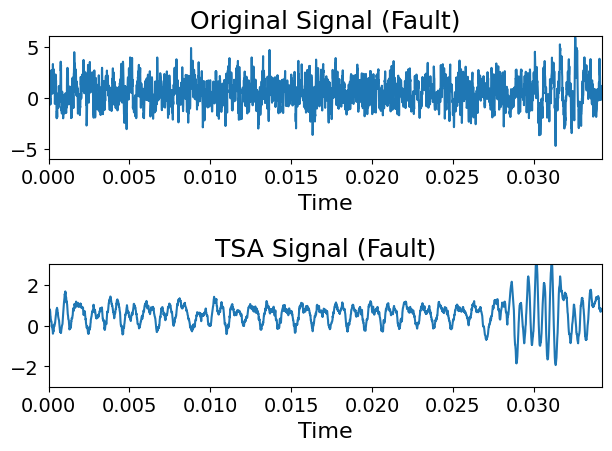

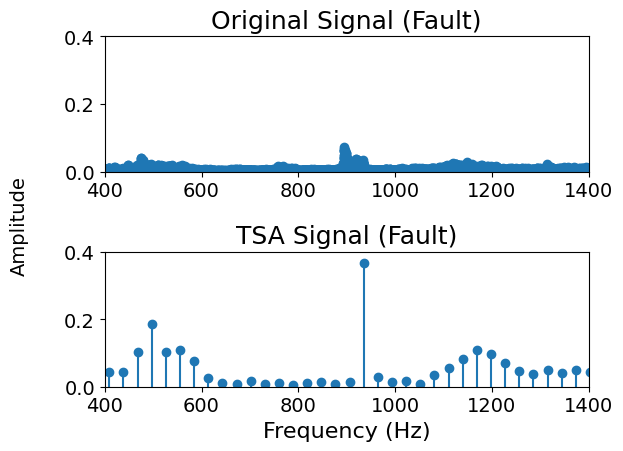

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft

gs = data['gs'].flatten()
ppr = int(data['ppr'].flatten()[0])
sr = int(data['sr'].flatten()[0])
tach = data['tach'].flatten()
teeth = int(data['teeth'].flatten()[0])

x = gs
fs = sr

# Original-signal time vector
t = np.arange(len(x)) / fs

# Perform resampling and TSA
xa, t_tsa = sdol_tsa(x, fs, tach, ppr)

# Convert TSA signal to 1-D
xa = np.asarray(xa).squeeze()
t_tsa = np.asarray(t_tsa).squeeze()

# Number of samples
n = len(x)
na = len(xa)

# -------------------------------------------------
# Sampling and frequency information
# -------------------------------------------------

# Original-signal duration
T_raw = n / fs

# TSA equivalent sampling rate
dt_tsa = np.mean(np.diff(t_tsa))
fs_tsa = 1.0 / dt_tsa

# TSA period
T_tsa = na / fs_tsa

# Maximum frequencies (Nyquist frequencies)
fmax_raw = fs / 2
fmax_tsa = fs_tsa / 2

# Frequency resolutions
df_raw = fs / n
df_tsa = fs_tsa / na

# Print results
print(f'Number of original samples = {n}')
print(f'Nominal sampling frequency = {sr:.3f} Hz')
print(f'Actual sampling frequency = {n/6:.3f} Hz')

print(f'Number of resampled points per revolution, N = {na}')
print(f'TSA rotational period = {T_tsa:.6f} s')
print(f'TSA equivalent sampling frequency = {fs_tsa:.3f} Hz')

print(f'Original maximum frequency  = {fmax_raw:.2f} Hz')
print(f'TSA maximum frequency       = {fmax_tsa:.2f} Hz')
print(f'Original frequency resolution = {df_raw:.6f} Hz')
print(f'TSA frequency resolution      = {df_tsa:.6f} Hz')

# -------------------------------------------------
# Time-domain plots
# -------------------------------------------------

plt.figure()

plt.subplot(2, 1, 1)
plt.plot(t[:na], x[:na])
plt.xlabel('Time')
plt.title(f'Original Signal ({case_label})')
plt.ylim([-6, 6])
plt.xlim([0, T_tsa])

plt.subplot(2, 1, 2)
plt.plot(t_tsa, xa)
plt.xlabel('Time')
plt.title(f'TSA Signal ({case_label})')
plt.ylim([-3, 3])
plt.xlim([0, T_tsa])

plt.tight_layout()

# -------------------------------------------------
# FFT of original signal
# -------------------------------------------------

f = np.arange(0, n) / n * fs
f = f[:math.ceil(n / 2)]

X = np.abs(fft(x)) / n * 2
X = X[:math.ceil(n / 2)]

# -------------------------------------------------
# FFT of TSA signal
# -------------------------------------------------

fa = np.arange(0, na) / na * fs_tsa
fa = fa[:math.ceil(na / 2)]

Xa = np.abs(fft(xa)) / na * 2
Xa = Xa[:math.ceil(na / 2)]

# -------------------------------------------------
# Frequency-domain plots
# -------------------------------------------------

fig = plt.figure(2)

plt.subplot(211)
plt.stem(f, X, basefmt=' ')
plt.title(f'Original Signal ({case_label})')
plt.xlim(400, 1400)
plt.ylim(0, 0.40)

plt.subplot(212)
plt.stem(fa, Xa, basefmt=' ')
plt.title(f'TSA Signal ({case_label})')
plt.xlim(400, 1400)
plt.ylim(0, 0.40)
plt.xlabel('Frequency (Hz)')

fig.supylabel('Amplitude', size=14)

plt.tight_layout()
plt.show()

## Signal decomposition by Wavelet

### CWT of truncated sine wave

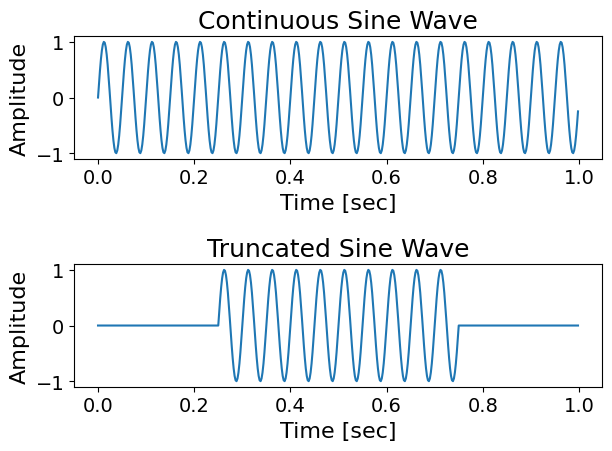

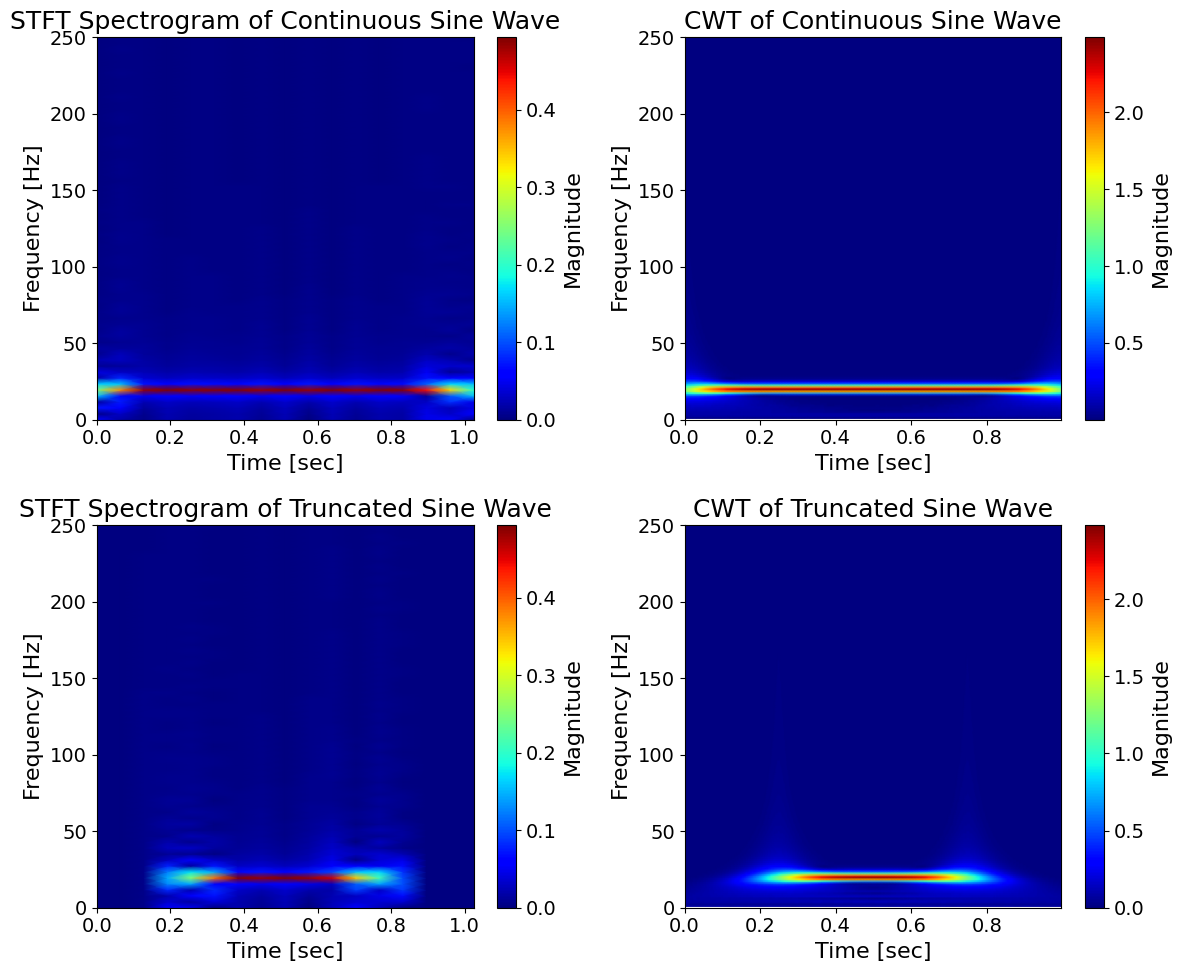

In [ ]:
# Import modules
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import pywt

fs = 500
T = 1
t = np.arange(0, T, 1/fs)
n = len(t)

p = 20

x1 = np.sin(2 * np.pi * p * t)

i1 = np.argmin(np.abs(t - 0.25))
i2 = np.argmin(np.abs(t - 0.75))

x2 = np.zeros_like(t)
x2[i1:i2] = np.sin(2 * np.pi * p * t[i1:i2])

plt.figure()

plt.subplot(211)
plt.plot(t, x1)
plt.title('Continuous Sine Wave')
plt.xlabel('Time [sec]')
plt.ylabel('Amplitude')

plt.subplot(212)
plt.plot(t, x2)
plt.title('Truncated Sine Wave')
plt.xlabel('Time [sec]')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


# Input : x (signal), fs, ax (matplotlib axis), [nperseg, overlap_ratio if present]
# Output: draws STFT spectrogram on ax, returns the image handle
def stft_plot(x, fs, ax):
    nperseg = 128
    noverlap = nperseg * 3 // 4

    f, tt, Zxx = signal.stft(
        x, fs,
        window='boxcar',
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nperseg,
        return_onesided=True,
        boundary='zeros',
        padded=True
    )

    Zxx_mag = np.abs(Zxx)
    im = ax.pcolormesh(tt, f, Zxx_mag, shading='gouraud', cmap='jet')

    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    ax.set_ylim(0, fs/2)
    return im


# Input : x (signal), fs, ax (matplotlib axis)
# Output: draws CWT scalogram on ax, returns the image handle
def cwt_plot(x, fs, ax):
    # Complex (analytic) Morlet wavelet: avoids the oscillating "ripple"
    # artifact seen with the real-valued 'morl' wavelet's magnitude.
    wavelet = 'cmor6.0-1.0'
    target_freqs = np.linspace(1, fs / 2, 200)
    scales = pywt.central_frequency(wavelet) * fs / target_freqs

    coeffs, freqs = pywt.cwt(x, scales, wavelet, sampling_period=1/fs)

    cwt_mag = np.abs(coeffs)

    im = ax.pcolormesh(t, freqs, cwt_mag, shading='gouraud', cmap='jet')

    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    ax.set_ylim(0, fs/2)
    return im


fig = plt.figure(figsize=(12, 10))

# STFT spectrograms
ax1 = fig.add_subplot(221)
im1 = stft_plot(x1, fs, ax1)
ax1.set_title('STFT Spectrogram of Continuous Sine Wave')
plt.colorbar(im1, ax=ax1, label='Magnitude')

ax2 = fig.add_subplot(223)
im2 = stft_plot(x2, fs, ax2)
ax2.set_title('STFT Spectrogram of Truncated Sine Wave')
plt.colorbar(im2, ax=ax2, label='Magnitude')

# CWT scalograms
ax3 = fig.add_subplot(222)
im3 = cwt_plot(x1, fs, ax3)
ax3.set_title('CWT of Continuous Sine Wave')
plt.colorbar(im3, ax=ax3, label='Magnitude')

ax4 = fig.add_subplot(224)
im4 = cwt_plot(x2, fs, ax4)
ax4.set_title('CWT of Truncated Sine Wave')
plt.colorbar(im4, ax=ax4, label='Magnitude')

plt.tight_layout()
plt.show()

### STFT & CWT of simulation signal

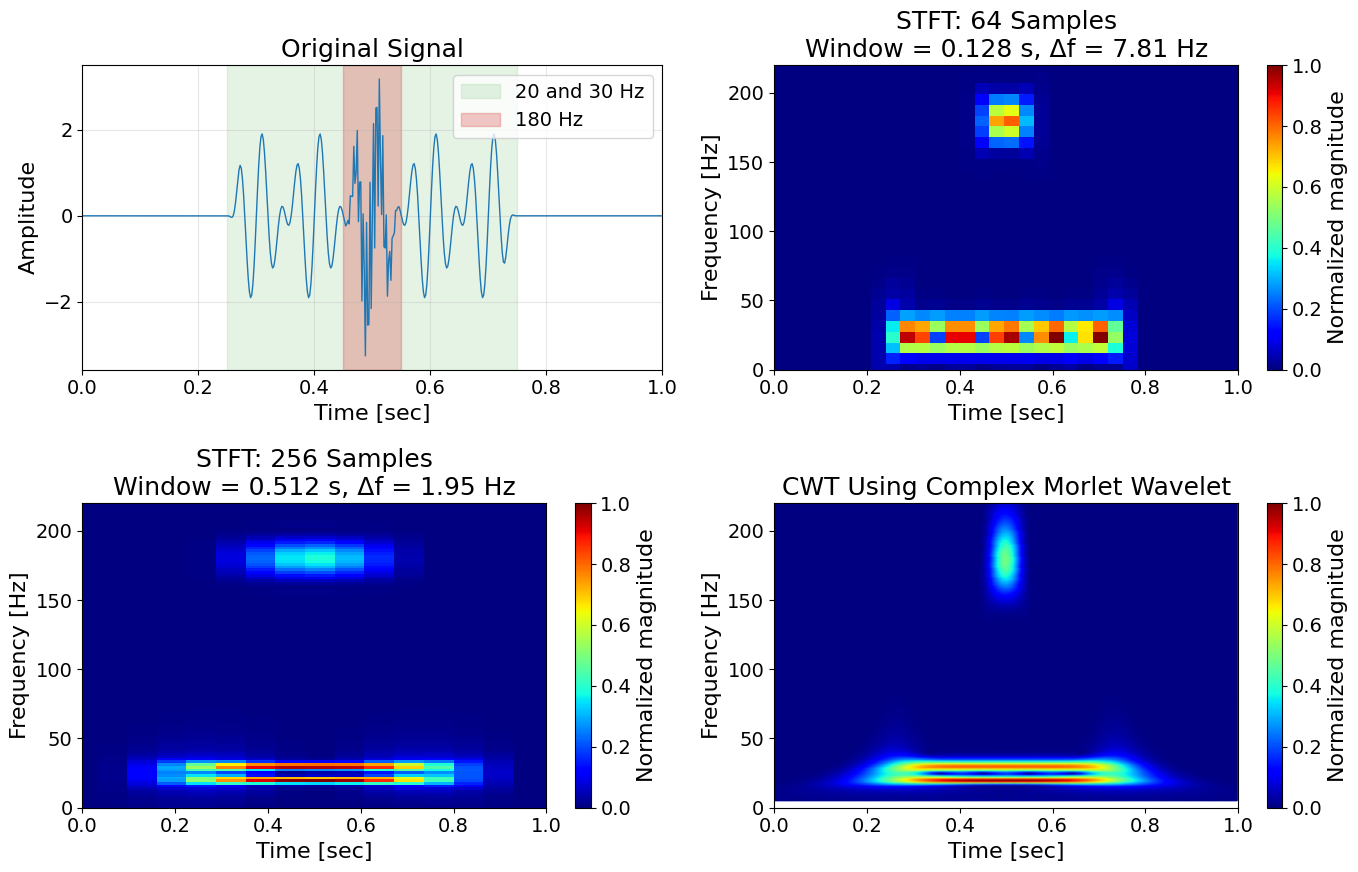

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal

# 1. Signal generation
fs, T = 500, 1.0
t = np.arange(int(fs * T)) / fs

low_mask = (t >= 0.25) & (t < 0.75)
high_mask = (t >= 0.45) & (t < 0.55)

x_20 = np.zeros_like(t)
x_30 = np.zeros_like(t)
x_180 = np.zeros_like(t)

low_window = signal.windows.tukey(low_mask.sum(), alpha=0.1)
high_window = np.hanning(high_mask.sum())

x_20[low_mask] = low_window * np.sin(2 * np.pi * 20 * t[low_mask])
x_30[low_mask] = low_window * np.sin(2 * np.pi * 30 * t[low_mask])
x_180[high_mask] = 2 * high_window * np.sin(2 * np.pi * 180 * t[high_mask])
x = x_20 + x_30 + x_180

# 2. STFT
# Input : x (signal), fs, ax (matplotlib axis), [nperseg, overlap_ratio if present]
# Output: draws STFT spectrogram on ax, returns the image handle
def stft_plot(x, fs, ax, nperseg, overlap_ratio):
    noverlap = int(nperseg * overlap_ratio)
    f, tt, Z = signal.stft(x, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap, nfft=nperseg, boundary='zeros', padded=True)
    magnitude = np.abs(Z)
    magnitude /= magnitude.max()

    im = ax.pcolormesh(tt, f, magnitude, shading='nearest', cmap='jet', vmin=0, vmax=1, edgecolors='none', antialiased=False)
    ax.set(
        xlim=(0, 1), ylim=(0, 220), xlabel='Time [sec]',
        ylabel='Frequency [Hz]',
        title=f'STFT: {nperseg} Samples\n'
              f'Window = {nperseg/fs:.3f} s, Δf = {fs/nperseg:.2f} Hz'
    )
    return im

# 3. CWT
# Input : x (signal), fs, ax (matplotlib axis)
# Output: draws CWT scalogram on ax, returns the image handle
def cwt_plot(x, fs, t, ax):
    wavelet = 'cmor6.0-1.0'
    target_freqs = np.linspace(5, 220, 216)
    scales = pywt.central_frequency(wavelet) * fs / target_freqs

    coefficients, frequencies = pywt.cwt(x, scales, wavelet, sampling_period=1 / fs)
    magnitude = np.abs(coefficients)
    magnitude /= magnitude.max()

    im = ax.pcolormesh(t, frequencies, magnitude, shading='gouraud', cmap='jet', vmin=0, vmax=1)
    ax.set(
        xlim=(0, 1), ylim=(0, 220), xlabel='Time [sec]',
        ylabel='Frequency [Hz]',
        title='CWT Using Complex Morlet Wavelet'
    )
    return im

# 4. Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(t, x, color='tab:blue', linewidth=1)
ax.axvspan(0.25, 0.75, color='tab:green', alpha=0.12, label='20 and 30 Hz')
ax.axvspan(0.45, 0.55, color='tab:red', alpha=0.25, label='180 Hz')
ax.set(xlim=(0, 1), xlabel='Time [sec]', ylabel='Amplitude', title='Original Signal')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

im1 = stft_plot(x, fs, axes[0, 1], nperseg=64, overlap_ratio=0.75)
im2 = stft_plot(x, fs, axes[1, 0], nperseg=256, overlap_ratio=0.875)
im3 = cwt_plot(x, fs, t, axes[1, 1])

for ax, im in zip([axes[0, 1], axes[1, 0], axes[1, 1]], [im1, im2, im3]):
    fig.colorbar(im, ax=ax, label='Normalized magnitude')

plt.tight_layout()
plt.show()

### Mother wavelets

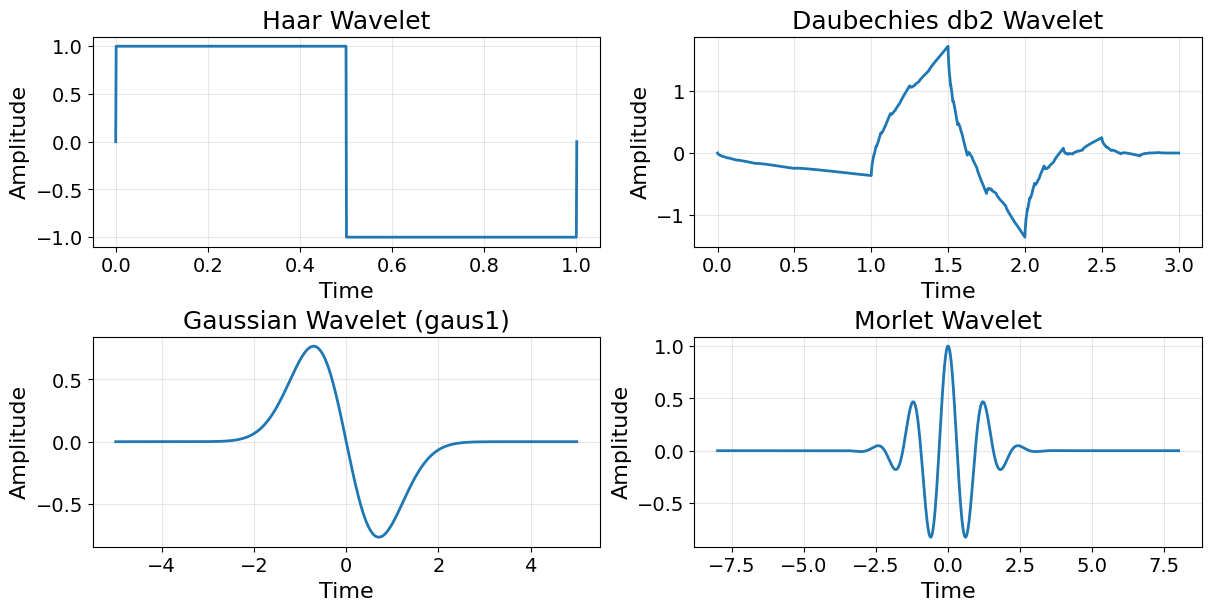

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Haar and db2 from discrete wavelet family
phi_haar, psi_haar, x_haar = pywt.Wavelet('haar').wavefun(level=10)
phi_db2, psi_db2, x_db2 = pywt.Wavelet('db2').wavefun(level=10)

# Gaussian and Morlet from continuous wavelet family
psi_gaus, x_gaus = pywt.ContinuousWavelet('gaus1').wavefun(level=10)
psi_morl, x_morl = pywt.ContinuousWavelet('morl').wavefun(level=10)


fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)

axes[0, 0].plot(x_haar, psi_haar, linewidth=2)
axes[0, 0].set_title('Haar Wavelet')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x_db2, psi_db2, linewidth=2)
axes[0, 1].set_title('Daubechies db2 Wavelet')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(x_gaus, psi_gaus, linewidth=2)
axes[1, 0].set_title('Gaussian Wavelet (gaus1)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x_morl, psi_morl, linewidth=2)
axes[1, 1].set_title('Morlet Wavelet')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(True, alpha=0.3)

plt.show()

### DWT of Lelecum signal

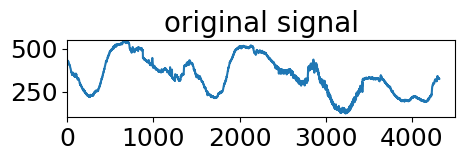

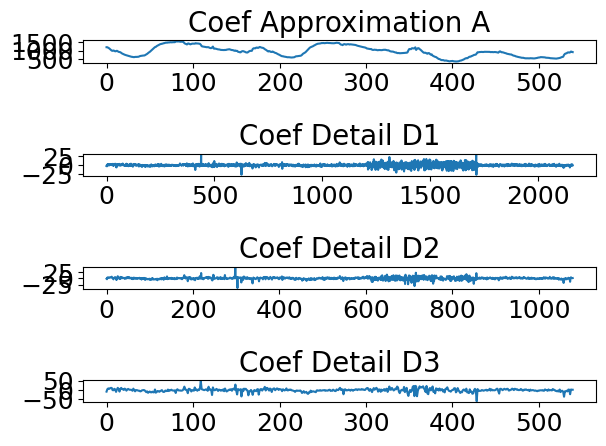

In [ ]:
# Import modules

from scipy import io
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = io.loadmat('/content/drive/MyDrive/PHM SUNYK/Datasets/Lelecum.mat') # noissin, leleccum
s = data['leleccum'][0]
ls = len(s)

plt.figure(figsize=(5,1))
plt.plot(s)
plt.xlim([0, 4500])
plt.ylim([100, 550])
plt.title('original signal')
plt.show()
wv = 'db1'

cA3, cD3, cD2, cD1 = pywt.wavedec(s, wv, level=3)

plt.figure()
plt.subplot(411)
plt.plot(cA3)
plt.title('Coef Approximation A')
plt.subplot(412)
plt.plot(cD1)
plt.title('Coef Detail D1')
plt.subplot(413)
plt.plot(cD2)
plt.title('Coef Detail D2')
plt.subplot(414)
plt.plot(cD3)
plt.title('Coef Detail D3')
plt.tight_layout()
plt.show()

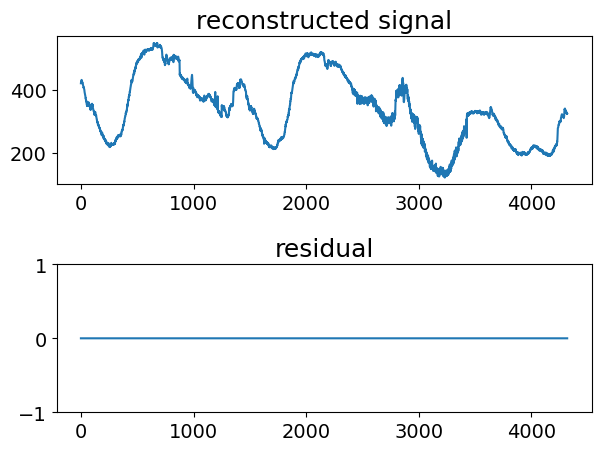

In [ ]:
# Signal reconstructions

A3 = pywt.upcoef('a', cA3, wv, level=3, take=len(s))
D3 = pywt.upcoef('d', cD3, wv, level=3, take=len(s))
D2 = pywt.upcoef('d', cD2, wv, level=2, take=len(s))
D1 = pywt.upcoef('d', cD1, wv, level=1, take=len(s))

sr = A3 + D1 + D2 + D3

plt.figure()
plt.subplot(211)
plt.plot(sr)
plt.title('reconstructed signal')
plt.subplot(212)
plt.plot(s-sr)
plt.title('residual')
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### WPD of robot motor signal

robot shape = (59998, 12)


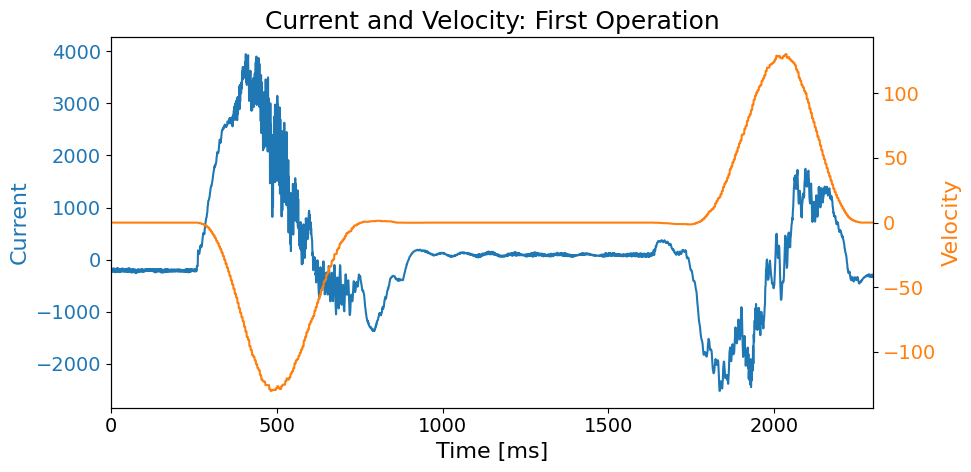

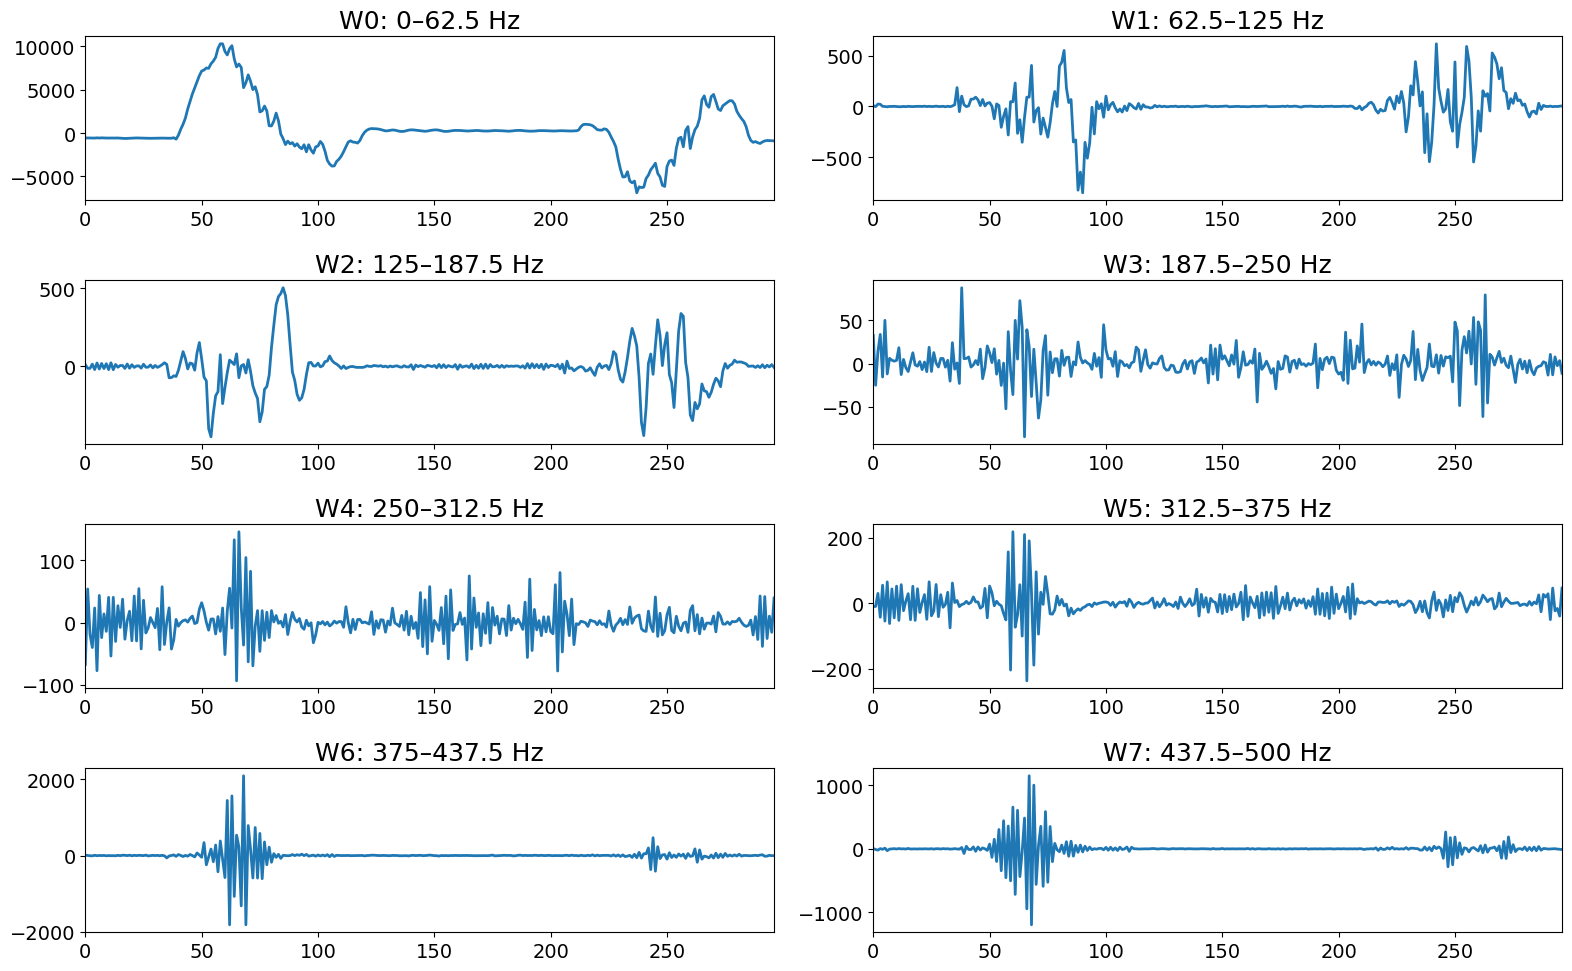

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat

file_path = ('/content/drive/MyDrive/PHM SUNYK/Datasets/Robot/0000_00_01.mat')

data = loadmat(file_path)
robot = np.asarray(data['robot'])
print('robot shape =', robot.shape)

# First operation
current = robot[:2300, 0]   # MATLAB column 1
velocity = robot[:2300, 4]  # MATLAB column 5

sample_index = np.arange(2300)

# -------------------------------------------------
# Current and velocity
# -------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(sample_index, current, color='tab:blue')
ax1.set_xlabel('Time [ms]')
ax1.set_ylabel('Current', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlim(0, 2299)

ax2 = ax1.twinx()

ax2.plot(sample_index, velocity, color='tab:orange')
ax2.set_ylabel('Velocity', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Current and Velocity: First Operation')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# WPD of current signal
# -------------------------------------------------

x = current

wp = pywt.WaveletPacket(data=x, wavelet='db6', mode='symmetric', maxlevel=3)

nodes = wp.get_level(3, order='freq')

freq_bands = [
    '0–62.5 Hz',
    '62.5–125 Hz',
    '125–187.5 Hz',
    '187.5–250 Hz',
    '250–312.5 Hz',
    '312.5–375 Hz',
    '375–437.5 Hz',
    '437.5–500 Hz'
]

plt.figure(figsize=(16, 10))

for i, node in enumerate(nodes):
    plt.subplot(4, 2, i + 1)
    plt.plot(node.data, linewidth=2.0)
    plt.title(f'W{i}: {freq_bands[i]}')
    plt.xlim(0, len(node.data) - 1)

plt.tight_layout()
plt.show()